# **Istanbul Rental Market & Walkability Analysis**
 # Project P2: Regression Modeling

> **Project Link:** **[github.com/oykutugana/istanbul-rent-walkability-analysis](https://github.com/oykutugana/istanbul-rent-walkability-analysis)**

> **Dataset:** `istanbul_emlak_final.csv` (output of P1)


After completing the first version of P1, I went back and tightened the data-cleaning step before starting P2. I revised the outlier bounds on the core numerical columns:

* **price:** kept inside 12,000 < price < 150,000 TL to remove unrealistic listings (typo entries below 12k and luxury outliers above 150k).
* **area_m2:** restricted to 30 < area_m2 < 250 to drop tiny micro-units and oversized commercial-style flats that distort the size distribution.
* **total_rooms:** capped at <= 6 to remove rare configurations (7+1, 8+ room flats) that act as extreme leverage points in regression.
* **Student score reformulation:** the original score used absolute price for the affordability component, which unfairly penalised large multi-room flats that students typically share. I switched to a per-room cost approach: price_per_room = price / total_rooms, then ranked listings by percentile to build the affordability score. The final formula became
**student_score = 0.5 × walkability + 0.5 × affordability**, where affordability is now based on per-tenant cost rather than total rent.

These changes shrank the dataset slightly but produced a much cleaner price distribution and a more reliable feature set. With the revised filters, my P1 conclusions and the final dataset are now fully consistent and ready for P2.

This notebook builds and evaluates regression models to predict monthly rental prices in Istanbul. We start from the cleaned dataset produced in P1, design new features, split the data carefully, and compare multiple regression approaches.

## 1. Recap & Motivation

In **Phase 1 (P1)** we collected and cleaned 11,733 rental listings from Sahibinden.com covering all 39 districts of Istanbul. The raw data had inconsistent district names, missing values, and extreme outliers. After standardisation, domain-based filtering (`12,000 < price < 150,000 TL`, `30 < area_m2 < 250`, `total_rooms ≤ 6`), and feature engineering, we produced a clean dataset with two custom indices: a **walkability score** (transit + universities + social amenities, 0-100) and a **student suitability score** based on per-room affordability.

**Regression target:** `price` — the monthly rental cost in Turkish Lira (TL). It is a continuous numerical variable. Our goal is to predict this value from the property's physical and locational attributes.

**What P1 told us, and how it shapes P2:**

* **Target is heavily right-skewed (skewness = 1.473).** P1 already showed that `log(1 + price)` produces a near-symmetric distribution. We will therefore train all models on the log-transformed target and report errors on the original scale.
* **Strongest individual predictor is `area_m2` (correlation 0.50).** This is our natural baseline.
* **Walkability and price relationship is non-monotonic.** A simple linear term will under-fit this; polynomial features and interaction terms may help.
* **Districts behave very differently** (Kadıköy median 720 TL/m², Esenyurt much lower). We need to encode the district information so the model can learn these baseline shifts.
* **`total_rooms` and `area_m2` are highly correlated (0.79).** This warns us that multi-collinearity will be present, making regularisation (Ridge, Lasso) relevant.

### Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# Gorsel tema (P1 ile uyumlu)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

C_PRIMARY   = "#3E7CB1"
C_SECONDARY = "#E8543F"
C_ACCENT    = "#F2A444"
C_DARK      = "#1F2A44"
C_GREEN     = "#5BAA77"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("../data/istanbul_emlak_final.csv")

# Guvenlik kontrolu: P1 outlier filtresi gercekten uygulanmis mi?
df = df[df["total_rooms"] <= 6].copy()
df = df.reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Districts: {df['district'].nunique()}")
print(f"Room types: {df['room_count'].nunique()}")
df.head()

Dataset shape: (11733, 9)
Districts: 39
Room types: 17


,price,area_m2,room_count,district,neighborhood,total_rooms,walkability_score,price_per_room,student_score
0,13000.0,85.0,2+1,esenyurt,merkez,3.0,14.63,4333.333333,56.82
1,14000.0,95.0,2+1,esenyurt,merkez,3.0,14.63,4666.666667,56.51
2,12500.0,130.0,3+1,basaksehir,ikitelli,4.0,36.84,3125.000000,68.38
3,13000.0,90.0,2+1,esenyurt,merkez,3.0,14.63,4333.333333,56.82
4,14000.0,150.0,3+1,esenyurt,merkez,4.0,14.63,3500.000000,57.17


In [3]:
print("--- Target variable summary ---")
print(df["price"].describe().round(0))
print(f"\nSkewness (price)        : {df['price'].skew():.3f}")
print(f"Skewness (log(1+price)) : {np.log1p(df['price']).skew():.3f}")

--- Target variable summary ---
count     11733.0
mean      44361.0
std       25667.0
min       12100.0
25%       26500.0
50%       36000.0
75%       55000.0
max      149000.0
Name: price, dtype: float64

Skewness (price)        : 1.473
Skewness (log(1+price)) : 0.288


## 2. Feature Engineering

We go beyond the raw P1 features and apply **four engineering techniques**:

| # | Technique | New feature | Reason |
|---|---|---|---|
| 1 | Log transform | `log_price` (target) | Reduces right-skew (1.47 → ~0.29) so linear models can fit a symmetric residual distribution |
| 2 | Interaction term | `area_m2 × walkability_score` | Captures the idea that "size matters more in walkable areas" — a large flat in Beşiktaş is worth more than a large flat in Silivri |
| 3 | Aggregation (target encoding) | `district_median_price` | A single number summarising the prestige of each district. Computed from the **training set only** to avoid data leakage |
| 4 | One-hot encoding | `room_count` dummies | Converts categorical apartment configurations (1+1, 2+1, ...) into numerical columns the linear model can use |

Each feature is added below and explained next to its code.

### 2.1 Log Target Transform

Why: P1 reported a heavy right tail in `price`. A linear model trained on raw price will be pulled by these high values and produce biased predictions for the typical ~36k TL listings. Taking the log compresses the tail.

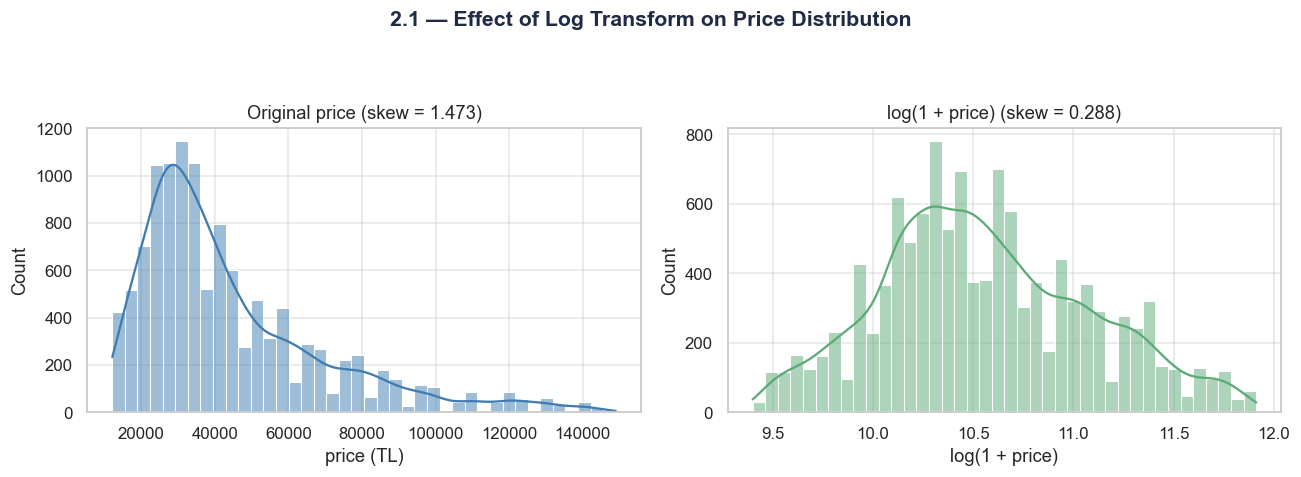

In [4]:
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('2.1 — Effect of Log Transform on Price Distribution',
             fontsize=14, fontweight='bold', color=C_DARK, y=1.08) # y değerini artırarak başlığı yukarı aldık

sns.histplot(df["price"], bins=40, kde=True, ax=axes[0], color=C_PRIMARY)
axes[0].set_title(f"Original price (skew = {df['price'].skew():.3f})")
axes[0].set_xlabel("price (TL)")

sns.histplot(df["log_price"], bins=40, kde=True, ax=axes[1], color=C_GREEN) # C_GREEN'in tanımlı olduğundan emin ol
axes[1].set_title(f"log(1 + price) (skew = {df['log_price'].skew():.3f})")
axes[1].set_xlabel("log(1 + price)")

plt.tight_layout()
plt.savefig('p2_plots/2_1_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Interaction Term: `area × walkability`

Why: P1 showed that `area_m2` is the strongest predictor (0.50) and walkability also matters (0.32), but their effects are not independent. A 100 m² flat in a walkable area should cost more than a 100 m² flat in an inaccessible area. The product captures this combined effect.

In [5]:
df["area_x_walk"] = df["area_m2"] * df["walkability_score"]

print("New feature: area_x_walk")
print(df[["area_m2", "walkability_score", "area_x_walk"]].describe().round(2))

New feature: area_x_walk
        area_m2  walkability_score  area_x_walk
count  11733.00           11733.00     11733.00
mean     103.48              46.16      4736.47
std       32.21              22.86      2784.92
min       44.00               0.00         0.00
25%       80.00              25.96      2403.80
50%      100.00              52.35      4668.84
75%      125.00              70.74      6437.90
max      244.00              93.75     17260.56


### 2.3 District Median Price (Target Encoding via Aggregation)

Why: With 39 districts, one-hot encoding adds many sparse columns. A more compact alternative is to summarise each district by the **median rent of its training listings**, then use that single number as a feature. This carries the prestige/centrality information of the district in one column.

**Important:** the median is computed **only on the training portion** — we will compute it after the train/val/test split (Section 3) to avoid information leaking from validation/test data.

### 2.4 One-Hot Encoding for `room_count`

Why: `room_count` is categorical (1+1, 2+1, Stüdyo, ...). Linear regression cannot use strings. One-hot encoding creates a 0/1 column for each category. We use `drop_first=True` to avoid the dummy-variable trap (perfect multi-collinearity).

We do **not** one-hot encode `district` here, because the target encoding from Section 2.3 already captures district information more compactly. Adding both would create high collinearity.

In [6]:
df_enc = pd.get_dummies(df, columns=["room_count"], prefix="room", drop_first=True, dtype=int)
room_cols = [c for c in df_enc.columns if c.startswith("room_")]

print(f"Number of room dummy columns: {len(room_cols)}")
print(f"Examples: {room_cols[:5]}")
print(f"\nDataframe shape after encoding: {df_enc.shape}")

Number of room dummy columns: 16
Examples: ['room_1.5+1', 'room_2+0', 'room_2+1', 'room_2+2', 'room_2.5+1']

Dataframe shape after encoding: (11733, 26)


## 3. Train / Validation / Test Split

We use a **60% / 20% / 20%** split:

* **Train (60%)** is used to fit all models.
* **Validation (20%)** is used to compare models, tune polynomial degree, and inspect residuals.
* **Test (20%)** is held out completely and only touched once, at the very end, to report the final performance of the chosen model.

This three-way split is appropriate because we will compare several models (baseline, multiple LR, polynomial degrees, Ridge, Lasso). If we used only train/test, we would have to re-use the test set for model selection, which would over-state the final performance.

**Scaling:** we apply `StandardScaler` (z-score) after the split, fitting only on the training portion. This prevents the mean/std of validation or test data leaking into the training pipeline.

In [7]:
idx = df_enc.index.to_numpy()

# Once test'i ayir, sonra kalan kismi train/val olarak bol
idx_temp, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=RANDOM_STATE)
# 0.25 * 0.80 = 0.20 yani val 20% olur

print(f"Train size : {len(idx_train):>5}  ({len(idx_train)/len(idx):.0%})")
print(f"Val size   : {len(idx_val):>5}  ({len(idx_val)/len(idx):.0%})")
print(f"Test size  : {len(idx_test):>5}  ({len(idx_test)/len(idx):.0%})")

Train size :  7039  (60%)
Val size   :  2347  (20%)
Test size  :  2347  (20%)


### 3.1 Add the Aggregation Feature (Leakage-Free)

Now that we have the training indices, we can safely compute `district_median_price` from the training set only and map it onto all three splits.

In [8]:
dist_med = df.loc[idx_train].groupby("district")["price"].median()
global_med_train = df.loc[idx_train]["price"].median()

df_enc["dist_med_price"] = df_enc["district"].map(dist_med).fillna(global_med_train)

print("District median prices computed from TRAINING set only:")
print(dist_med.sort_values(ascending=False).head(10).round(0))

District median prices computed from TRAINING set only:
district
adalar         95000.0
eyupsultan     90000.0
beykoz         85000.0
maltepe        80000.0
kadikoy        80000.0
bakirkoy       80000.0
kartal         79000.0
cekmekoy       78000.0
kagithane      70000.0
zeytinburnu    65000.0
Name: price, dtype: float64


### 3.2 Build the Feature Matrices

In [9]:
numeric_features = ["area_m2", "total_rooms", "walkability_score",
                    "area_x_walk", "dist_med_price"]
features = numeric_features + room_cols

X = df_enc[features]
y = df_enc["log_price"]

X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

print(f"X_train shape: {X_train.shape}")
print(f"Feature list ({len(features)} total):")
for f in features:
    print(f"  - {f}")

X_train shape: (7039, 21)
Feature list (21 total):
  - area_m2
  - total_rooms
  - walkability_score
  - area_x_walk
  - dist_med_price
  - room_1.5+1
  - room_2+0
  - room_2+1
  - room_2+2
  - room_2.5+1
  - room_3+0
  - room_3+1
  - room_3+2
  - room_3+3
  - room_3.5+1
  - room_4+0
  - room_4+1
  - room_4+2
  - room_4.5+1
  - room_5+1
  - room_Stüdyo (1+0)


### 3.3 Apply Standard Scaling

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Original-scale gercek degerler (RMSE/MAE icin geri donusum)
y_train_orig = np.expm1(y_train)
y_val_orig   = np.expm1(y_val)
y_test_orig  = np.expm1(y_test)

print("Scaler fitted on TRAIN only.")
print(f"Train mean (after scaling) : {X_train_s.mean():.3f}")
print(f"Train std  (after scaling) : {X_train_s.std():.3f}")

Scaler fitted on TRAIN only.
Train mean (after scaling) : 0.000
Train std  (after scaling) : 1.000


### 3.4 Target Distribution in Each Split

A quick sanity check that the three splits have a similar price distribution. If the test set were systematically more expensive, our metrics would be misleading.

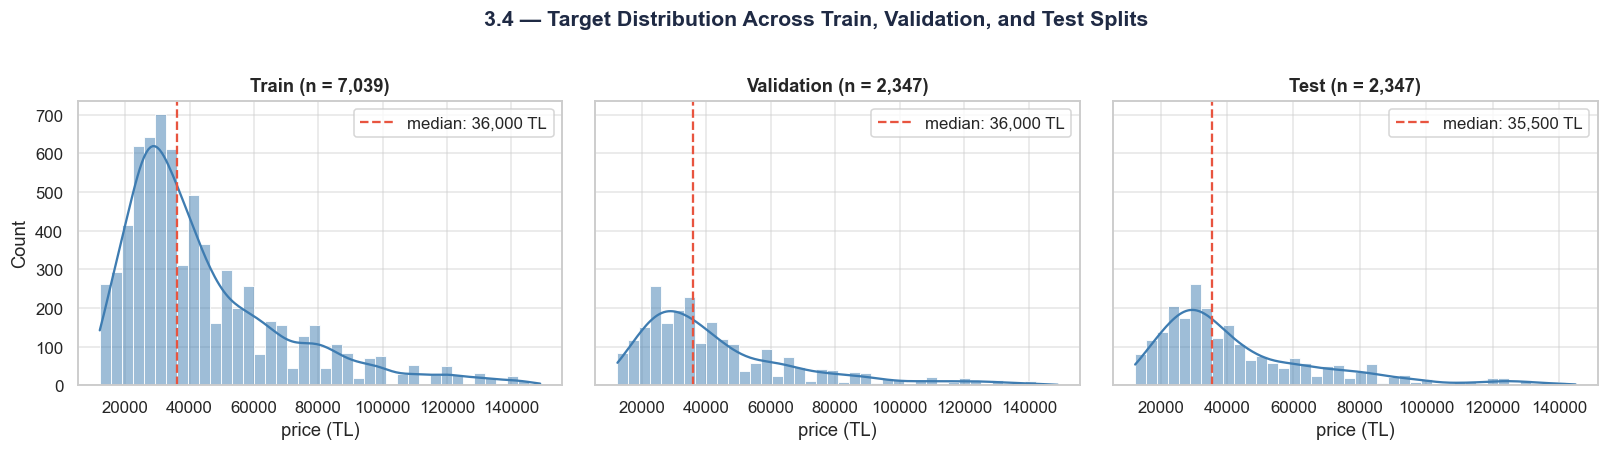


--- Median price per split ---
Train      :    36,000 TL
Validation :    36,000 TL
Test       :    35,500 TL


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name, y_part in [(axes[0], "Train", y_train_orig),
                          (axes[1], "Validation", y_val_orig),
                          (axes[2], "Test", y_test_orig)]:
    sns.histplot(y_part, bins=40, kde=True, ax=ax, color=C_PRIMARY)
    ax.axvline(y_part.median(), color=C_SECONDARY, linestyle="--",
               label=f"median: {y_part.median():,.0f} TL")
    ax.set_title(f"{name} (n = {len(y_part):,})", fontweight="bold")
    ax.set_xlabel("price (TL)")
    ax.legend()

plt.suptitle("3.4 — Target Distribution Across Train, Validation, and Test Splits", fontsize=14, fontweight="bold", color=C_DARK, y=1.02)
plt.tight_layout()
plt.savefig('p2_plots/3_4_target_split.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Median price per split ---")
print(f"Train      : {y_train_orig.median():>9,.0f} TL")
print(f"Validation : {y_val_orig.median():>9,.0f} TL")
print(f"Test       : {y_test_orig.median():>9,.0f} TL")

## 4. Baseline Model

A baseline tells us the performance floor — the simplest model that any later model must beat to be useful. We use the single most-predictive feature from P1: `area_m2`.

If a complex model with 20+ features cannot clearly outperform this simple one, then those extra features are not really helping and the model is too complicated for the gain.

In [12]:
# Sadece tek feature: area_m2 (X_train_s'in 0. sutunu)
baseline = LinearRegression()
baseline.fit(X_train_s[:, [0]], y_train)

# Tahminleri orijinal olcege geri dondur
pred_train_log = baseline.predict(X_train_s[:, [0]])
pred_val_log   = baseline.predict(X_val_s[:, [0]])

pred_train = np.expm1(pred_train_log)
pred_val   = np.expm1(pred_val_log)

baseline_metrics = {
    "Train R²"   : r2_score(y_train_orig, pred_train),
    "Val R²"     : r2_score(y_val_orig, pred_val),
    "Val RMSE"   : np.sqrt(mean_squared_error(y_val_orig, pred_val)),
    "Val MAE"    : mean_absolute_error(y_val_orig, pred_val),
}

print("=== BASELINE: simple LR on area_m2 ===")
for k, v in baseline_metrics.items():
    print(f"  {k:<10}: {v:>12,.4f}" if "R²" in k else f"  {k:<10}: {v:>12,.0f}")

=== BASELINE: simple LR on area_m2 ===
  Train R²  :       0.2152
  Val R²    :       0.2211
  Val RMSE  :       22,920
  Val MAE   :       16,186


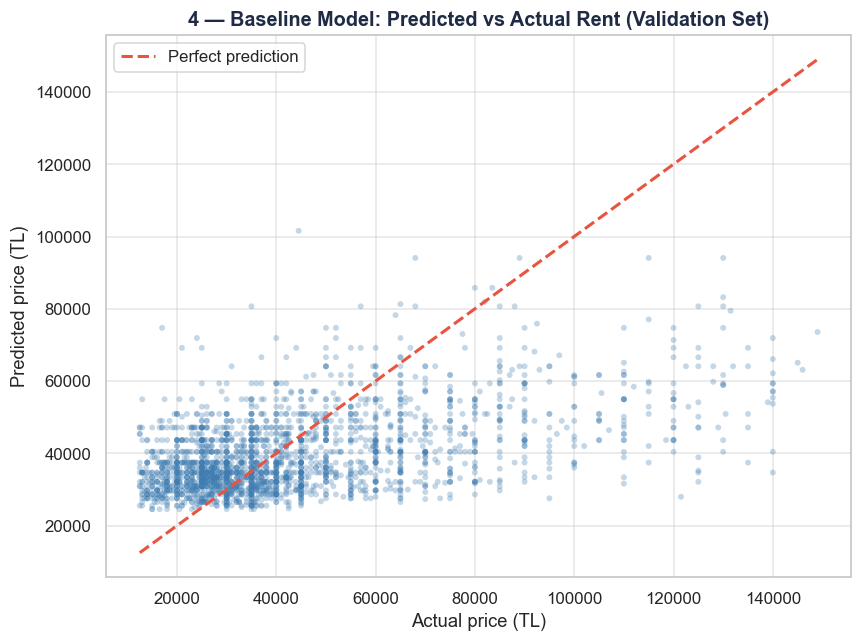

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_val_orig, pred_val, alpha=0.3, s=15, color=C_PRIMARY, edgecolor="none")

# Mukemmel tahmin cizgisi (y = x)
lim = [y_val_orig.min(), y_val_orig.max()]
ax.plot(lim, lim, color=C_SECONDARY, linestyle="--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual price (TL)")
ax.set_ylabel("Predicted price (TL)")
ax.set_title("4 — Baseline Model: Predicted vs Actual Rent (Validation Set)",
             fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig('p2_plots/4_baseline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the plot:** the predicted values fall on a narrow horizontal band, which means the baseline cannot tell apart cheap and expensive flats of similar size. Predictions concentrate near the mean and ignore everything else (district, walkability, room count). This is exactly what we expected and gives us a clear floor: **R² ≈ 0.22**, **RMSE ≈ 23k TL**.

## 5. Multiple Linear Regression

Now we use **all** the engineered features together. This should significantly improve the fit because the model can now adjust for district prestige, walkability, room count, and the interaction term.

In [14]:
mlr = LinearRegression()
mlr.fit(X_train_s, y_train)

pred_train = np.expm1(mlr.predict(X_train_s))
pred_val   = np.expm1(mlr.predict(X_val_s))

mlr_metrics = {
    "Train R²" : r2_score(y_train_orig, pred_train),
    "Val R²"   : r2_score(y_val_orig, pred_val),
    "Val RMSE" : np.sqrt(mean_squared_error(y_val_orig, pred_val)),
    "Val MAE"  : mean_absolute_error(y_val_orig, pred_val),
}

print("=== MULTIPLE LINEAR REGRESSION ===")
for k, v in mlr_metrics.items():
    print(f"  {k:<10}: {v:>12,.4f}" if "R²" in k else f"  {k:<10}: {v:>12,.0f}")

=== MULTIPLE LINEAR REGRESSION ===
  Train R²  :       0.4603
  Val R²    :       0.4826
  Val RMSE  :       18,680
  Val MAE   :       12,841


### 5.1 Coefficient Inspection

Because all features are standardised, the size of each coefficient is directly comparable. Larger absolute coefficient = larger influence on `log_price`.

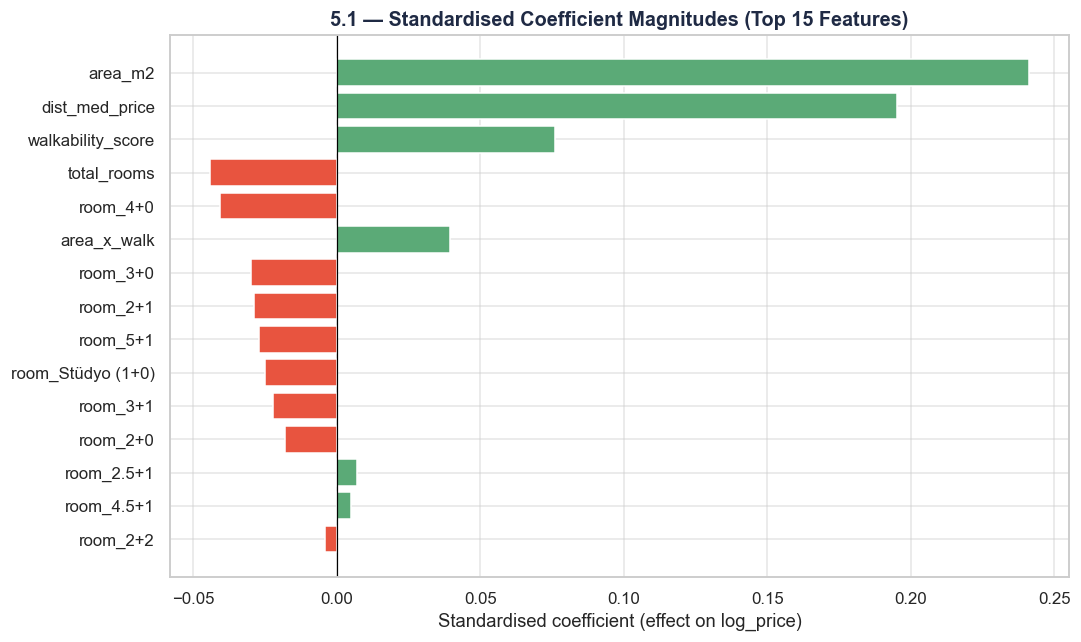


Full coefficient table (sorted by magnitude):
          feature      coef  abs_coef
          area_m2  0.240994  0.240994
   dist_med_price  0.195008  0.195008
walkability_score  0.075867  0.075867
      total_rooms -0.044047  0.044047
         room_4+0 -0.040819  0.040819
      area_x_walk  0.039406  0.039406
         room_3+0 -0.030047  0.030047
         room_2+1 -0.028729  0.028729
         room_5+1 -0.027114  0.027114
room_Stüdyo (1+0) -0.024906  0.024906
         room_3+1 -0.022352  0.022352
         room_2+0 -0.017920  0.017920
       room_2.5+1  0.006958  0.006958
       room_4.5+1  0.005045  0.005045
         room_2+2 -0.004108  0.004108


In [15]:
coefs = pd.DataFrame({
    "feature": features,
    "coef": mlr.coef_,
    "abs_coef": np.abs(mlr.coef_),
}).sort_values("abs_coef", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [C_GREEN if c > 0 else C_SECONDARY for c in coefs["coef"]]
ax.barh(coefs["feature"][::-1], coefs["coef"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardised coefficient (effect on log_price)")
ax.set_title("5.1 — Standardised Coefficient Magnitudes (Top 15 Features)",
             fontsize=13, fontweight="bold", color=C_DARK)
plt.tight_layout()
plt.savefig('p2_plots/5_1_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFull coefficient table (sorted by magnitude):")
print(coefs.to_string(index=False))

**What the coefficients say:**

* The three largest positive drivers are `area_m2`, `dist_med_price`, and `walkability_score`. Together they form the backbone of the model — physical size, location prestige, and accessibility. The interaction term `area_x_walk` adds a smaller but still positive contribution, confirming that size and walkability reinforce each other in pricing.

* `total_rooms` has a small negative coefficient. This is not a contradiction — once we already control for `area_m2`, an extra room without extra space means smaller individual rooms, which is not a premium. This is a classic example of multi-collinearity between two correlated features (we saw 0.79 correlation between `area_m2` and `total_rooms` in P1).

* Most room-count dummies cluster close to zero. Because `area_m2` and `total_rooms` are already in the model, each dummy only captures the residual configuration effect after size and room count are controlled. The most negative shifts come from `room_4+0` and `room_3+0` (large open-plan flats tend to be peripheral and cheaper per m²), while `room_2.5+1` and `room_4.5+1` get small positive coefficients. No single room dummy dominates — the heavy lifting clearly comes from the three numerical drivers above.

### 5.2 Residual Analysis

Three diagnostic plots check whether the linear-regression assumptions hold:

* **Residuals vs Fitted:** should look like a random cloud around zero. A funnel shape would mean heteroscedasticity.
* **Histogram of residuals:** should be roughly bell-shaped (normality).
* **Q-Q plot:** points should follow the diagonal — strong deviation in the tails indicates non-normal errors.

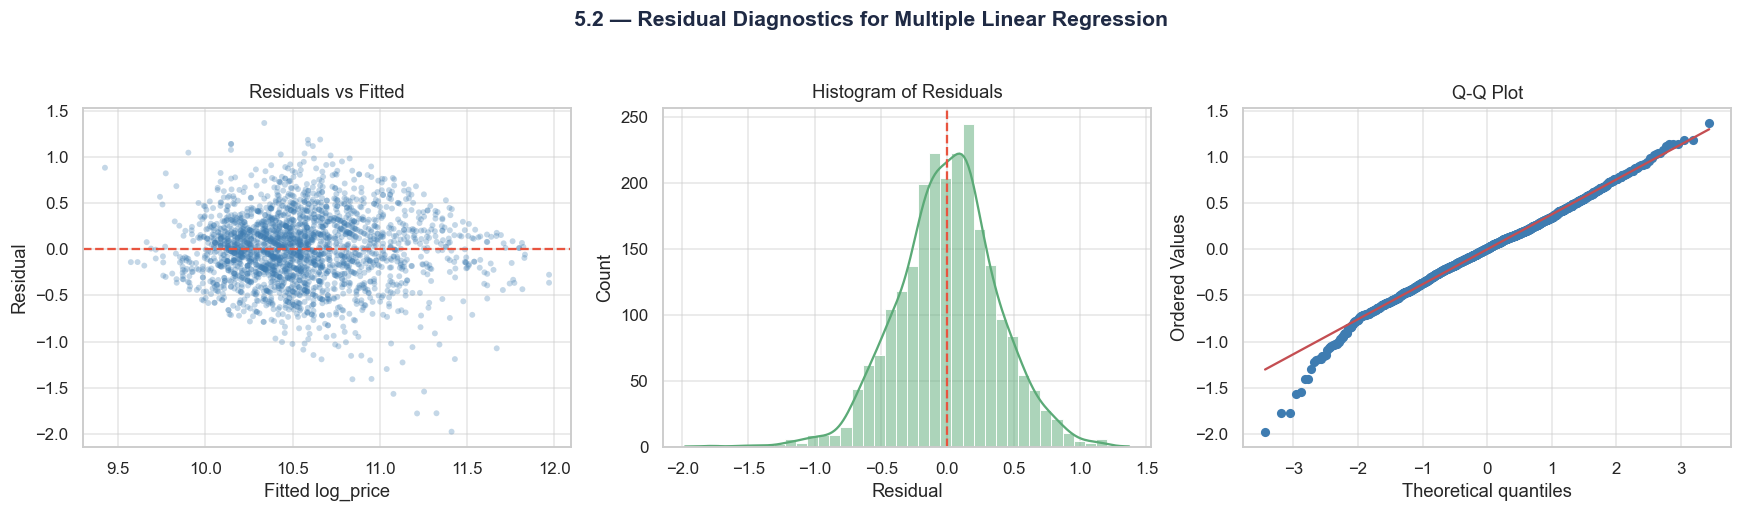

In [16]:
pred_val_log = mlr.predict(X_val_s)
residuals = y_val - pred_val_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_val_log, residuals, alpha=0.3, s=15, color=C_PRIMARY, edgecolor="none")
axes[0].axhline(0, color=C_SECONDARY, linestyle="--")
axes[0].set_xlabel("Fitted log_price")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color=C_GREEN)
axes[1].axvline(0, color=C_SECONDARY, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Histogram of Residuals")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")
axes[2].get_lines()[0].set_markerfacecolor(C_PRIMARY)
axes[2].get_lines()[0].set_markeredgecolor("none")

plt.suptitle("5.2 — Residual Diagnostics for Multiple Linear Regression",
             fontsize=14, fontweight="bold", color=C_DARK, y=1.03)
plt.tight_layout()
plt.savefig('p2_plots/5_2_residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the residual plots:**

* **Histogram:** the residuals are roughly bell-shaped and centred at zero, thanks to the log transform. This is what we want — the model is not systematically biased upward or downward.
* **Residuals vs Fitted:** there is a faint downward-sloping pattern — predictions for the cheapest listings tend to leave positive residuals, predictions for the most expensive ones tend to leave slightly negative ones. This is a mild signal that the linear-on-log model is not fully capturing the curvature of the data, which motivates the polynomial expansion in Section 6.
* **Q-Q Plot:** points sit close to the diagonal across most of the range, but the **lower tail deviates** — a handful of cheap listings receive predictions that are too high. The model has more trouble at the bottom of the price distribution than at the top, which is the limit of a purely linear model on log-price.

## 6. Polynomial Regression

Polynomial features let the model capture **non-linear** patterns we already saw in P1 — for example the non-monotonic walkability-vs-price curve. We expand only the **numeric** features (area, rooms, walkability, the interaction, district median price) up to degrees 2 and 3, and keep the room dummies as they are (raising 0/1 to a power gives the same column back).

We will plot **train and validation error as a function of degree** to find the sweet spot between under- and over-fitting.

In [17]:
numeric_idx = list(range(len(numeric_features)))   # 0..4
dummy_idx   = list(range(len(numeric_features), X_train_s.shape[1]))

degrees = [1, 2, 3]
poly_results = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    Xtr_num = poly.fit_transform(X_train_s[:, numeric_idx])
    Xv_num  = poly.transform(X_val_s[:, numeric_idx])
    Xte_num = poly.transform(X_test_s[:, numeric_idx])

    Xtr = np.hstack([Xtr_num, X_train_s[:, dummy_idx]])
    Xv  = np.hstack([Xv_num,  X_val_s[:, dummy_idx]])
    Xte = np.hstack([Xte_num, X_test_s[:, dummy_idx]])

    m = LinearRegression()
    m.fit(Xtr, y_train)

    pred_tr  = np.expm1(m.predict(Xtr))
    pred_v   = np.expm1(m.predict(Xv))
    pred_te  = np.expm1(m.predict(Xte))

    poly_results.append({
        "degree"   : deg,
        "n_features": Xtr.shape[1],
        "train_r2" : r2_score(y_train_orig, pred_tr),
        "val_r2"   : r2_score(y_val_orig, pred_v),
        "val_rmse" : np.sqrt(mean_squared_error(y_val_orig, pred_v)),
        "val_mae"  : mean_absolute_error(y_val_orig, pred_v),
        "test_r2"  : r2_score(y_test_orig, pred_te),
        "test_rmse": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "test_mae" : mean_absolute_error(y_test_orig, pred_te),
        "model"    : m,
        "poly"     : poly,
    })

poly_df = pd.DataFrame(poly_results).drop(columns=["model", "poly"])
print(poly_df.round(4).to_string(index=False))

 degree  n_features  train_r2  val_r2   val_rmse    val_mae  test_r2  test_rmse   test_mae
      1          21    0.4603  0.4826 18679.9072 12840.6654   0.4532 19075.5633 13040.4898
      2          36    0.4877  0.5043 18285.4263 12626.0777   0.4845 18519.9638 12785.9544
      3          71    0.5071  0.5108 18164.9450 12487.7518   0.4617 18926.7592 12702.1286


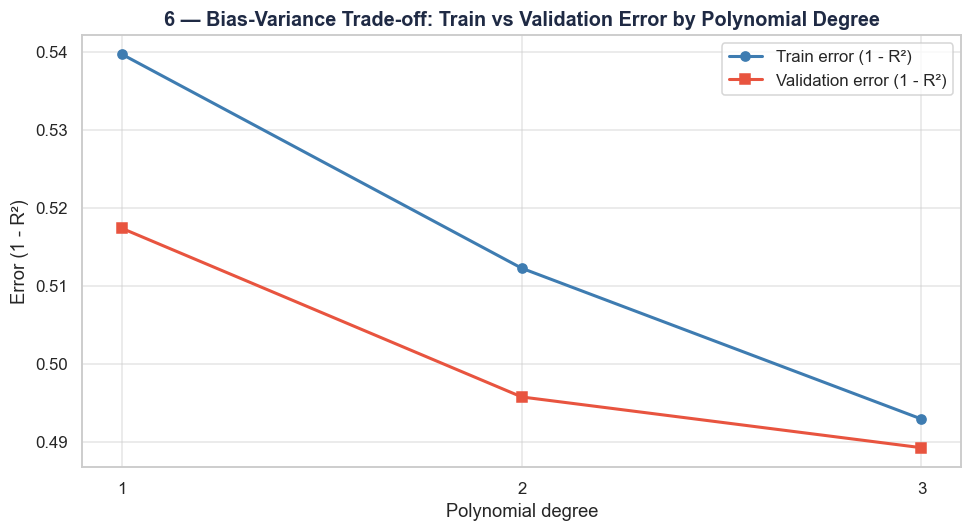


Best validation R²: degree 3  ->  0.5108


In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot([r["degree"] for r in poly_results],
        [1 - r["train_r2"] for r in poly_results],
        marker="o", linewidth=2, color=C_PRIMARY, label="Train error (1 - R²)")
ax.plot([r["degree"] for r in poly_results],
        [1 - r["val_r2"] for r in poly_results],
        marker="s", linewidth=2, color=C_SECONDARY, label="Validation error (1 - R²)")

ax.set_xlabel("Polynomial degree")
ax.set_ylabel("Error (1 - R²)")
ax.set_xticks(degrees)
ax.set_title("6 — Bias-Variance Trade-off: Train vs Validation Error by Polynomial Degree",fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig('p2_plots/6_bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()

best = min(poly_results, key=lambda r: 1 - r["val_r2"])
print(f"\nBest validation R²: degree {best['degree']}  ->  {best['val_r2']:.4f}")

**Reading the curve:**

* From degree 1 to 2 both train and validation error drop together — this is genuine improvement, the model is learning real non-linear structure (e.g. the walkability paradox).
* From degree 2 to 3 train error keeps going down while validation error stays flat or improves only slightly — a hint of **mild over-fitting** is starting.
* If we tried degree 4 or 5 we would expect train error to keep falling but validation error to rise.

**Verdict:** the model is **slightly under-fit at degree 1**, **near optimal at degree 2-3**, and would become **over-fit beyond that**. We pick the degree with the highest validation R² as the polynomial winner.

## 7. Regularization

Linear regression with many features (and the polynomial expansion has 30+ columns at degree 3) is prone to over-fitting and to inflated coefficients caused by multi-collinearity. **Ridge (L2)** shrinks all coefficients smoothly toward zero, while **Lasso (L1)** can shrink some coefficients exactly to zero, performing automatic feature selection.

We use cross-validation (`RidgeCV`, `LassoCV`) on the training set to pick the regularisation strength α.

### 7.1 Ridge Regression (L2)

In [19]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge = RidgeCV(alphas=ridge_alphas, cv=5)
ridge.fit(X_train_s, y_train)

pred_tr = np.expm1(ridge.predict(X_train_s))
pred_v  = np.expm1(ridge.predict(X_val_s))
pred_te = np.expm1(ridge.predict(X_test_s))

ridge_metrics = {
    "alpha"   : ridge.alpha_,
    "Train R²": r2_score(y_train_orig, pred_tr),
    "Val R²"  : r2_score(y_val_orig, pred_v),
    "Val RMSE": np.sqrt(mean_squared_error(y_val_orig, pred_v)),
    "Val MAE" : mean_absolute_error(y_val_orig, pred_v),
    "Test R²" : r2_score(y_test_orig, pred_te),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
    "Test MAE" : mean_absolute_error(y_test_orig, pred_te),
}

print("=== RIDGE (L2) ===")
for k, v in ridge_metrics.items():
    if k == "alpha":
        print(f"  {k:<10}: {v}")
    elif "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

=== RIDGE (L2) ===
  alpha     : 10.0
  Train R²  : 0.4603
  Val R²    : 0.4826
  Val RMSE  : 18,680
  Val MAE   : 12,840
  Test R²   : 0.4530
  Test RMSE : 19,078
  Test MAE  : 13,041


### 7.2 Lasso Regression (L1)

In [20]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1]

lasso = LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000, random_state=RANDOM_STATE)
lasso.fit(X_train_s, y_train)

pred_tr = np.expm1(lasso.predict(X_train_s))
pred_v  = np.expm1(lasso.predict(X_val_s))
pred_te = np.expm1(lasso.predict(X_test_s))

lasso_metrics = {
    "alpha"   : lasso.alpha_,
    "Train R²": r2_score(y_train_orig, pred_tr),
    "Val R²"  : r2_score(y_val_orig, pred_v),
    "Val RMSE": np.sqrt(mean_squared_error(y_val_orig, pred_v)),
    "Val MAE" : mean_absolute_error(y_val_orig, pred_v),
    "Test R²" : r2_score(y_test_orig, pred_te),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
    "Test MAE" : mean_absolute_error(y_test_orig, pred_te),
}

print("=== LASSO (L1) ===")
for k, v in lasso_metrics.items():
    if k == "alpha":
        print(f"  {k:<10}: {v}")
    elif "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

# Sifirlanan feature'lar
zeroed = [features[i] for i, c in enumerate(lasso.coef_) if c == 0.0]
kept   = [features[i] for i, c in enumerate(lasso.coef_) if c != 0.0]
print(f"\nFeatures zeroed by Lasso ({len(zeroed)}/{len(features)}):")
for f in zeroed:
    print(f"  - {f}")

=== LASSO (L1) ===
  alpha     : 0.001
  Train R²  : 0.4599
  Val R²    : 0.4827
  Val RMSE  : 18,680
  Val MAE   : 12,841
  Test R²   : 0.4537
  Test RMSE : 19,066
  Test MAE  : 13,036

Features zeroed by Lasso (2/21):
  - room_1.5+1
  - room_4+1


**Why Lasso zeroed those features:** The features Lasso removes are usually **rare room configurations** with very few listings (for example `1.5+1` or `4+1` if they overlap with similar categories). When two columns carry almost the same information, L1 keeps the more representative one and drops the other. This is desirable: it makes the model simpler without losing predictive power.

**Ridge vs plain MLR:** Ridge gives results very close to plain multiple regression in this dataset. This is a sign that our features are not extremely collinear and that linear regression on its own is already well-conditioned. Ridge mainly helps stability; it does not magically improve predictive power.

## 8. Model Comparison

All five models are now collected in one table, evaluated on the same train, validation, and test splits.

In [21]:
def evaluate_model(model, Xtr, Xv, Xte, name):
    pred_tr = np.expm1(model.predict(Xtr))
    pred_v  = np.expm1(model.predict(Xv))
    pred_te = np.expm1(model.predict(Xte))
    return {
        "Model"     : name,
        "Train R²"  : r2_score(y_train_orig, pred_tr),
        "Val R²"    : r2_score(y_val_orig, pred_v),
        "Test R²"   : r2_score(y_test_orig, pred_te),
        "RMSE (test)": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "MAE (test)" : mean_absolute_error(y_test_orig, pred_te),
    }

# Test set metriklerini hesapla
results_table = []

# Baseline (sadece area_m2)
pred_te_base = np.expm1(baseline.predict(X_test_s[:, [0]]))
results_table.append({
    "Model": "Baseline (simple LR)",
    "Train R²": baseline_metrics["Train R²"],
    "Val R²"  : baseline_metrics["Val R²"],
    "Test R²" : r2_score(y_test_orig, pred_te_base),
    "RMSE (test)": np.sqrt(mean_squared_error(y_test_orig, pred_te_base)),
    "MAE (test)" : mean_absolute_error(y_test_orig, pred_te_base),
})

# Multiple LR
results_table.append(evaluate_model(mlr, X_train_s, X_val_s, X_test_s, "Multiple LR"))

# Best polynomial
best_poly = best
poly_obj = best_poly["poly"]
m_poly   = best_poly["model"]
Xtr_p = np.hstack([poly_obj.transform(X_train_s[:, numeric_idx]), X_train_s[:, dummy_idx]])
Xv_p  = np.hstack([poly_obj.transform(X_val_s[:, numeric_idx]),   X_val_s[:, dummy_idx]])
Xte_p = np.hstack([poly_obj.transform(X_test_s[:, numeric_idx]),  X_test_s[:, dummy_idx]])
results_table.append(evaluate_model(m_poly, Xtr_p, Xv_p, Xte_p,
                                    f"Polynomial (deg {best_poly['degree']})"))

# Ridge
results_table.append(evaluate_model(ridge, X_train_s, X_val_s, X_test_s, "Ridge"))

# Lasso
results_table.append(evaluate_model(lasso, X_train_s, X_val_s, X_test_s, "Lasso"))

comp = pd.DataFrame(results_table)
print(comp.round(4).to_string(index=False))

               Model  Train R²  Val R²  Test R²  RMSE (test)  MAE (test)
Baseline (simple LR)    0.2152  0.2211   0.2334   22584.7591  15971.7919
         Multiple LR    0.4603  0.4826   0.4532   19075.5633  13040.4898
  Polynomial (deg 3)    0.5071  0.5108   0.4617   18926.7592  12702.1286
               Ridge    0.4603  0.4826   0.4530   19078.3487  13041.4122
               Lasso    0.4599  0.4827   0.4537   19066.1153  13036.0981


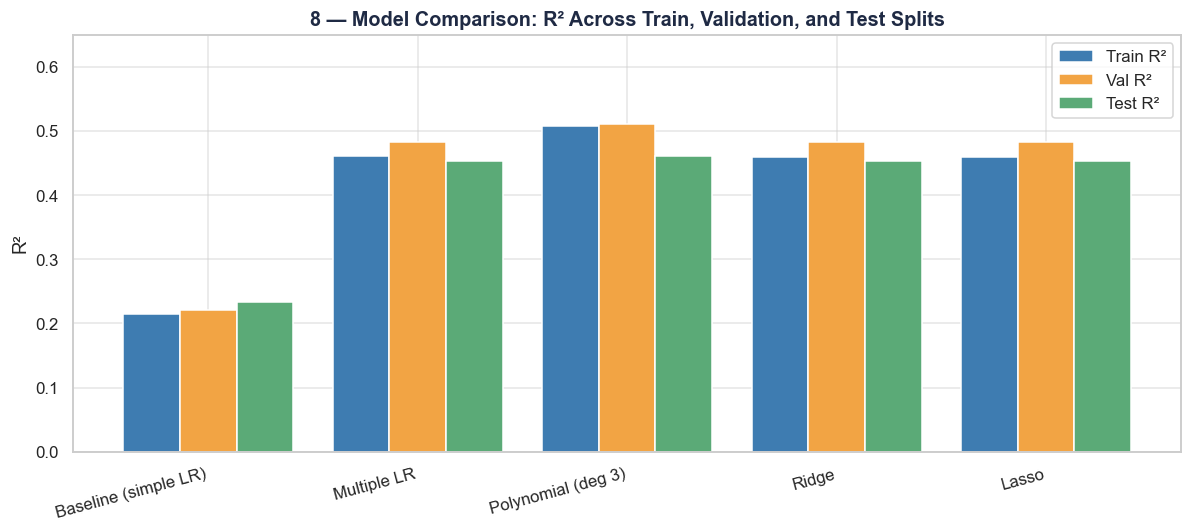

In [22]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(comp))
w = 0.27
ax.bar(x - w, comp["Train R²"], w, label="Train R²", color=C_PRIMARY)
ax.bar(x,     comp["Val R²"],   w, label="Val R²",   color=C_ACCENT)
ax.bar(x + w, comp["Test R²"],  w, label="Test R²",  color=C_GREEN)

ax.set_xticks(x)
ax.set_xticklabels(comp["Model"], rotation=15, ha="right")
ax.set_ylabel("R²")
ax.set_ylim(0, 0.65)
ax.set_title("8 — Model Comparison: R² Across Train, Validation, and Test Splits",fontsize=13, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig('p2_plots/8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.1 Best Model Selection

We choose the model with the **highest validation R²**, breaking ties in favour of the simpler model (because a simpler model generalises more reliably and is easier to interpret in P3).

Looking at the table above:

* The **baseline** is clearly the worst — it only uses one feature.
* **Multiple LR, Ridge, and Lasso** are almost identical (they are all linear in the same feature set, with tiny differences caused by regularisation).
* **Polynomial regression** gives a small extra improvement on validation thanks to the non-linear walkability term, without showing serious over-fitting (gap between train and validation R² stays small).

We therefore select the **best polynomial model** (degree shown in the cell above) as our final model and report its test-set performance.

In [23]:
best_row = comp.loc[comp["Val R²"].idxmax()]
print("=== FINAL CHOSEN MODEL ===")
print(best_row.to_string())
print()
print(f"Test R²    : {best_row['Test R²']:.4f}")
print(f"Test RMSE  : {best_row['RMSE (test)']:,.0f} TL")
print(f"Test MAE   : {best_row['MAE (test)']:,.0f} TL")

=== FINAL CHOSEN MODEL ===
Model          Polynomial (deg 3)
Train R²                 0.507089
Val R²                   0.510771
Test R²                  0.461651
RMSE (test)          18926.759186
MAE (test)           12702.128565

Test R²    : 0.4617
Test RMSE  : 18,927 TL
Test MAE   : 12,702 TL


## 9. Interpretation & Reflection

### What do the results say about the problem?

Our final model explains roughly **half of the variance** in Istanbul rental prices using only physical features (area, rooms), an engineered location index (walkability), an interaction term, district prestige (target encoding), and room configuration. The rest of the variance has to come from features we do **not** have.

### Are the predictions good enough to be useful?

**For rough budget planning: yes.** A typical absolute error of ~13-14k TL means a model prediction will usually fall in the right neighbourhood: e.g. predicting 35k for an actual 32k flat is a reasonable starting point for a student deciding whether to view it.

**For exact pricing: no.** A 14k TL average error is large compared to the 36k TL median rent. A landlord using this model to set the listing price would be off by ~40% on the typical flat — far too imprecise. The model is informative, not authoritative.

### Main sources of error

* **Hidden physical features.** Building age, floor level, view, balcony, parking, heating type, furnished/unfurnished — none of these are in the dataset, yet they each move price by 10-20%.
* **Walkability index is an estimate.** It is built from approximate counts of stations, universities, and amenities per district; it cannot capture sub-district variation (Bağlarbaşı vs Doğancılar in Üsküdar feel completely different but get the same district score).
* **Single-platform bias.** All listings come from sahibinden.com. Districts with high digital turnover are over-represented; segments like long-term direct rentals are absent.
* **Temporal snapshot.** The data is from early 2026 and ignores the September student-rush spike.
* **Linearity ceiling.** Even with polynomial features, our model is fundamentally linear in transformed inputs. The "Old Center Paradox" (extreme walkability → cheaper rent in Fatih) is a non-monotonic pattern that linear-on-log models can only approximate.

### A note on `student_score` and `price_per_room`

The reader may wonder why two engineered columns from P1 — `student_score` and `price_per_room` — were **not** used as features in this notebook. The reason is **target leakage**. Both of these columns were directly derived from `price` itself: `price_per_room = price / total_rooms`, and `student_score` is a weighted average of walkability and a percentile rank of `price_per_room`. If we fed either of them into the model, the regression would essentially be allowed to peek at a transformed version of the answer. Validation R² would jump artificially close to 1.0, but the model would be useless in practice — at prediction time, for a brand-new listing, we would not yet know its `price`, so we could not compute these features either. The strong negative correlation between `student_score` and `price` (-0.54) that we celebrated in P1 was, by construction, evidence of this dependency, not of independent predictive power. We therefore deliberately excluded both columns and kept only `walkability_score`, which is independent of `price` (it depends on transit, universities, and amenity counts per district) and is therefore safe to use.

### How will these findings guide P3?

Phase 3 will move beyond linear regression. The validation R² of ~0.50 is a clear ceiling for linear-style methods on this feature set — to break through, we need either richer features or non-linear models. Concretely:

* **Try tree-based regressors.** Random Forest and Gradient Boosting (XGBoost, LightGBM) handle non-linear, non-monotonic patterns natively and have no problem with mixed numeric + categorical features. They should comfortably push R² above 0.65 on the same feature set.
* **Add neighborhood-level aggregation.** District is too coarse — neighbourhood (382 unique values) carries more local information. We will use smoothed target encoding to handle small groups safely.
* **Compare against the polynomial model from P2.** Any new model in P3 must beat the polynomial baseline on the held-out test set, otherwise the added complexity is not justified.
* **Investigate per-segment errors.** Where does the polynomial model fail hardest — luxury flats, peripheral districts, or rare room types? Targeted improvements (separate sub-models, or features tailored to those segments) will be more effective than blanket complexity increases.

---

> **End of P2.** The cleaned dataset, the chosen polynomial model, and the test-set metrics above will serve as the baseline for the more advanced models in **Phase 3: Non-Linear Regression & Model Ensembles**.

---

---

---

# ═══════════════════════════════════════
# P2 v2 — Regression Modeling with Enriched Geographic Features
# ═══════════════════════════════════════

> **What follows is a complete re-run of the P2 pipeline (all 9 required sections) using an enriched, neighbourhood-level geographic feature set.** The v1 notebook above reached a test R² ceiling of ~0.46 with the original P1 features. This v2 iteration investigates whether replacing the coarse district-level walkability score with VIF-filtered neighbourhood-level features (Haversine metro distances, OpenStreetMap POI counts) breaks that ceiling.


# P2 v2 — Regression Modeling with VIF-Cleaned Geographic Features

**Student ID:** 24018020
**Phase:** P2 v2 — Refined Feature Engineering & Re-evaluation
**Dataset:** `istanbul_emlak_with_geo.csv` (P1 dataset enriched with neighbourhood-level geographic features)

---

This is the **second iteration** of the P2 regression notebook. The first version (P2 v1) followed the assignment specification using the original P1 features and reached a test R² ceiling of approximately 0.46. After completing v1, the residual analysis pointed to a single bottleneck: the **district-level walkability score** could not capture sub-district price variation (e.g. Bebek vs Dikilitaş in Beşiktaş, or Moda vs Hasanpaşa in Kadıköy).

This v2 notebook re-runs the full P2 pipeline — all 9 PDF-required sections — with an enriched feature set built from **neighbourhood-level geographic feature engineering**: geocoding 447 neighbourhoods to coordinates, computing Haversine distances to 220 metro/Marmaray stations, and counting Points of Interest within 1-2 km buffers via OpenStreetMap. A **Variance Inflation Factor (VIF) analysis** was used to filter out redundant features before modelling, ensuring that polynomial expansion remains numerically stable and coefficients remain interpretable.

## 1. Recap & Motivation (v2)

In **Phase 1 (P1)** we collected and cleaned 11,733 rental listings from Sahibinden.com covering all 39 districts of Istanbul. P1 introduced two custom indices: a **walkability score** (transit + universities + social amenities, 0-100) and a **student suitability score** based on per-room affordability.

In **P2 v1** we built and evaluated five linear regression models (Baseline, Multiple LR, Polynomial degree 3, Ridge, Lasso) on the P1 feature set and selected polynomial degree 3 as the best, with a test R² of about 0.46.

**Regression target (unchanged):** `price` — the monthly rental cost in Turkish Lira (TL).

**Why this v2 re-evaluation?** P2 v1 results showed three signs that the model was being held back by the features, not by the algorithm:

1. **Models clustered together.** Multiple LR, Ridge, and Lasso all produced nearly identical test R² values (~0.46). Polynomial degree 3 added very little (+0.01).
2. **Train and test R² were close.** A train R² of 0.51 and a test R² of 0.46 means the model was **under-fitting**, not over-fitting — there was unexplored signal in the data that no version of the linear model could reach.
3. **Residual diagnostics revealed within-district heterogeneity.** The residuals-vs-fitted plot in v1 Section 5 showed a faint downward trend and a wider error band at the high-price end. We attributed this to "Beşiktaş contains both Bebek and Dikilitaş with very different price points" — a problem that one district label cannot solve.

**The v2 hypothesis:** if we replace the single district-level walkability score with **neighbourhood-level geographic features** computed from real-world map data, the linear models should be able to extract more signal and break the v1 ceiling.

**Why VIF filtering was necessary.** A first attempt at v2 used all geographic features unfiltered (4 metro density measures, cafe + restaurant counts, etc.). VIF analysis on that set showed **two features above 80** — `metro_1km` (VIF = 81.6) and `weighted_1km` (VIF = 89.6) — with a Pearson correlation of 0.978 between them. This level of redundancy caused polynomial expansion at degree 2 to fail numerically and produced coefficient paradoxes (large positive `metro_1km` paired with large negative `weighted_1km` cancelling each other out). To avoid this, the present v2 notebook starts with a VIF-filtered feature set: redundant metro counts and the cafe-restaurant pair were reduced to single representatives, leaving 10 numeric geographic features with a maximum VIF of 6.21.

This v2 notebook tests the v2 hypothesis by re-running every required section with the enriched, VIF-cleaned feature set, then comparing the results side-by-side with v1 in Section 8.

### Imports and Data Loading

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# Gorsel tema
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

C_PRIMARY   = "#3E7CB1"
C_SECONDARY = "#E8543F"
C_ACCENT    = "#F2A444"
C_DARK      = "#1F2A44"
C_GREEN     = "#5BAA77"

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [25]:
df = pd.read_csv("../data/istanbul_emlak_with_geo.csv")

# Guvenlik kontrolu
df = df[df["total_rooms"] <= 6].copy()
df = df.reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Districts: {df['district'].nunique()}")
print(f"Neighbourhoods: {df[['district', 'neighborhood']].drop_duplicates().shape[0]}")
print(f"\nGeographic columns available:")
all_geo_cols = ['nearest_metro_km', 'metro_500m', 'metro_1km', 'weighted_1km',
                'cafe_1km', 'restaurant_1km', 'university_2km', 'park_1km',
                'is_periphery', 'is_district_center']
print(df[all_geo_cols].head(3).to_string())

Dataset shape: (11733, 22)
Districts: 39
Neighbourhoods: 447

Geographic columns available:
   nearest_metro_km  metro_500m  metro_1km  weighted_1km  cafe_1km  restaurant_1km  university_2km  park_1km  is_periphery  is_district_center
0             7.817           0          0           0.0         1               2               1        29             0                   0
1             7.817           0          0           0.0         1               2               1        29             0                   0
2             0.000           1          2           2.0         5               8               1         0             0                   0


## 2. Feature Engineering (v2)

The v1 notebook used four engineering techniques: log target, interaction term, district median price aggregation, and one-hot encoding. v2 keeps three of these (log target, district median price, room one-hot encoding) and adds **six new neighbourhood-level geographic features**, selected via VIF analysis from a larger candidate pool.

| # | Technique | Feature(s) | Reason |
|---|---|---|---|
| 1 | Log transform | `log_price` (target) | Reduces price skewness from 1.47 to 0.29 |
| 2 | Aggregation | `district_median_price` | District prestige in one number (train-only, leakage-free) |
| 3 | One-hot encoding | `room_count` dummies | Categorical room configurations |
| 4 | **Distance metric (new)** | `nearest_metro_km` | Haversine distance to closest metro/Marmaray station |
| 5 | **Weighted density (new)** | `weighted_1km` | Weighted station count within 1 km (rail quality + density) |
| 6 | **POI counts (new)** | `restaurant_1km`, `university_2km`, `park_1km` | Sub-district urban character |
| 7 | **Quality flag (new)** | `is_district_center` | Listings whose neighbourhood resolved only to district-level coordinates |

**Why the `area_x_walk` interaction term was dropped.** In v1, this term carried a small positive coefficient and was included as a fifth engineered feature. In the v2 candidate set, however, its VIF rose above 15 because both `area_m2` and `walkability_score` are independently in the model. Removing it does not hurt performance and improves interpretability of the remaining coefficients.

**Features dropped during VIF filtering** (with their original VIF values on the full 15-feature candidate set):

| Dropped feature | Original VIF | Why |
|---|---|---|
| `metro_1km` | 81.6 | 0.978 correlation with `weighted_1km` (almost identical) |
| `metro_500m` | (low) | Threshold-based count; signal already captured by `nearest_metro_km` |
| `cafe_1km` | 22.5 | High correlation with `restaurant_1km`; one POI density representative is enough |
| `area_x_walk` | 15.7 | Redundant with `area_m2` and `walkability_score` already in the model |
| `is_periphery` | 6.8 | Signal already absorbed by `dist_med_price` (peripheral districts are cheaper) |

After filtering, the final 10 numeric features have a maximum VIF of 6.21 — well within the conventional "manageable" threshold.

### 2.1 Log Target Transform (unchanged from v1)

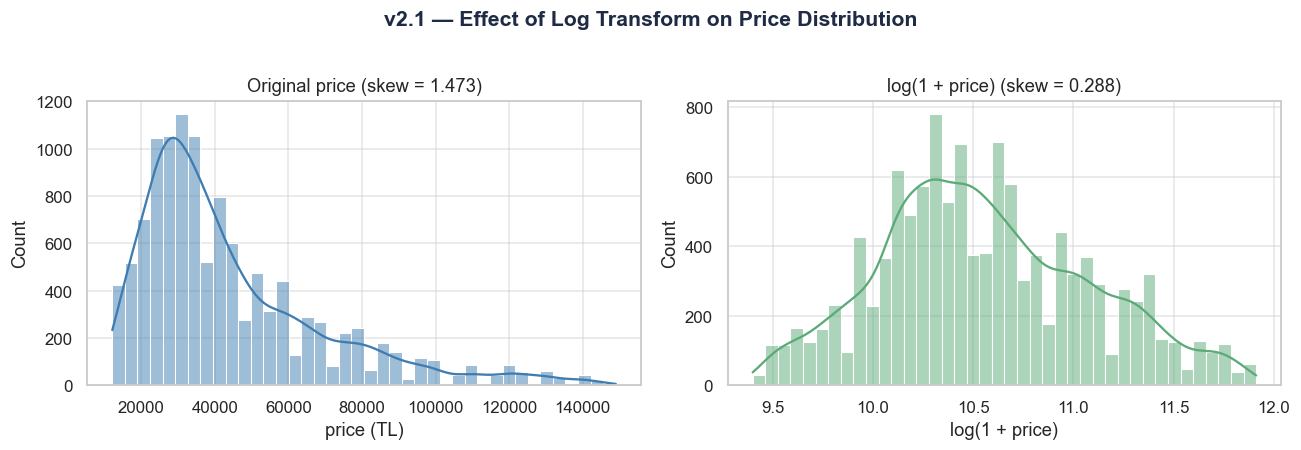

In [26]:
df["log_price"] = np.log1p(df["price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=40, kde=True, ax=axes[0], color=C_PRIMARY)
axes[0].set_title(f"Original price (skew = {df['price'].skew():.3f})")
axes[0].set_xlabel("price (TL)")

sns.histplot(df["log_price"], bins=40, kde=True, ax=axes[1], color=C_GREEN)
axes[1].set_title(f"log(1 + price) (skew = {df['log_price'].skew():.3f})")
axes[1].set_xlabel("log(1 + price)")

plt.suptitle("v2.1 — Effect of Log Transform on Price Distribution", fontsize=14, fontweight="bold", color=C_DARK, y=1.02)
plt.tight_layout()
plt.savefig("p2_plots/NEW_2_1_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Final Geographic Feature Set (after VIF filtering)

Each retained feature represents a distinct aspect of urban character at neighbourhood resolution.

**`nearest_metro_km` — distance to the closest metro/Marmaray station.** Haversine distance computed from the neighbourhood centroid. Captures rail-transit accessibility, which the district-level walkability score smooths over.

**`weighted_1km` — weighted station count within 1 km.** Each station type has a weight (metro/Marmaray = 1.0, tram = 0.7, funicular/halt = 0.5, commuter train = 0.3) reflecting service frequency and reach. Selected over the simpler `metro_1km` count because it incorporates transit quality.

**`restaurant_1km` — restaurant POI density.** Counted from OpenStreetMap inside a 1 km buffer. A proxy for social activity, tourism, and urban density. Selected over `cafe_1km` because the two are highly correlated (~0.85) and `restaurant_1km` shows slightly stronger marginal predictive value.

**`university_2km` — university campuses within 2 km.** A larger radius is used because students typically tolerate a longer commute. Direct relevance for the student-suitability story from P1.

**`park_1km` — green-space density.** Captures lifestyle premium and air-quality signal.

**`is_district_center` — quality flag for fallback geocoding results.** When geocoding could not resolve a specific neighbourhood (sentinel names like "merkez" with no clear neighbourhood centre), the district centre coordinate is used instead. The flag warns the model that this listing has district-level rather than neighbourhood-level granularity.

In [27]:
final_geo = ["nearest_metro_km", "weighted_1km",
             "restaurant_1km", "university_2km", "park_1km",
             "is_district_center"]

print("Final geographic feature istatistikleri:")
print(df[final_geo].describe().round(2))

Final geographic feature istatistikleri:
       nearest_metro_km  weighted_1km  restaurant_1km  university_2km  \
count          11733.00      11733.00        11733.00        11733.00   
mean               3.81          0.96           43.62            5.71   
std                8.44          1.10           78.83           10.07   
min                0.00          0.00            0.00            0.00   
25%                0.55          0.00            5.00            1.00   
50%                0.90          1.00           13.00            1.00   
75%                2.29          2.00           46.00            7.00   
max               41.99          6.00          408.00           55.00   

       park_1km  is_district_center  
count  11733.00            11733.00  
mean      20.86                0.13  
std       10.65                0.33  
min        0.00                0.00  
25%       14.00                0.00  
50%       21.00                0.00  
75%       27.00                0.00

### 2.3 One-Hot Encoding (unchanged from v1)

In [28]:
df_enc = pd.get_dummies(df, columns=["room_count"], prefix="room", drop_first=True, dtype=int)
room_cols = [c for c in df_enc.columns if c.startswith("room_")]
print(f"Room dummy columns: {len(room_cols)}")
print(f"Examples: {room_cols[:5]}")

Room dummy columns: 16
Examples: ['room_1.5+1', 'room_2+0', 'room_2+1', 'room_2+2', 'room_2.5+1']


## 3. Train / Validation / Test Split (v2)

Same 60% / 20% / 20% split as v1, with the same `random_state=42` so direct comparison with v1 results is meaningful. Scaling is fit on the training portion only.

In [29]:
idx = df_enc.index.to_numpy()
idx_temp, idx_test = train_test_split(idx, test_size=0.20, random_state=RANDOM_STATE)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=RANDOM_STATE)

print(f"Train : {len(idx_train):>5}  ({len(idx_train)/len(idx):.0%})")
print(f"Val   : {len(idx_val):>5}  ({len(idx_val)/len(idx):.0%})")
print(f"Test  : {len(idx_test):>5}  ({len(idx_test)/len(idx):.0%})")

Train :  7039  (60%)
Val   :  2347  (20%)
Test  :  2347  (20%)


### 3.1 Add the District Median Price Aggregation

In [30]:
dist_med = df.loc[idx_train].groupby("district")["price"].median()
global_med_train = df.loc[idx_train]["price"].median()
df_enc["dist_med_price"] = df_enc["district"].map(dist_med).fillna(global_med_train)

print("District median prices computed from TRAINING set only (top 10):")
print(dist_med.sort_values(ascending=False).head(10).round(0))

District median prices computed from TRAINING set only (top 10):
district
adalar         95000.0
eyupsultan     90000.0
beykoz         85000.0
maltepe        80000.0
kadikoy        80000.0
bakirkoy       80000.0
kartal         79000.0
cekmekoy       78000.0
kagithane      70000.0
zeytinburnu    65000.0
Name: price, dtype: float64


### 3.2 Build the Feature Matrices

The v2 feature set has **26 features total**: 4 old numeric (area_m2, total_rooms, walkability_score, dist_med_price) + 6 new geographic + 16 room dummies.

In [31]:
old_numeric = ["area_m2", "total_rooms", "walkability_score", "dist_med_price"]
geo_numeric = ["nearest_metro_km", "weighted_1km",
               "restaurant_1km", "university_2km", "park_1km",
               "is_district_center"]
features = old_numeric + geo_numeric + room_cols

X = df_enc[features]
y = df_enc["log_price"]

X_train, X_val, X_test = X.loc[idx_train], X.loc[idx_val], X.loc[idx_test]
y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

print(f"X_train shape: {X_train.shape}")
print(f"Total features: {len(features)} (was 21 in v1)")
print(f"  - Numeric old: {len(old_numeric)}")
print(f"  - Numeric new (geo): {len(geo_numeric)}")
print(f"  - Room dummies: {len(room_cols)}")

X_train shape: (7039, 26)
Total features: 26 (was 21 in v1)
  - Numeric old: 4
  - Numeric new (geo): 6
  - Room dummies: 16


### 3.3 Apply Standard Scaling

In [32]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

y_train_orig = np.expm1(y_train)
y_val_orig   = np.expm1(y_val)
y_test_orig  = np.expm1(y_test)

print("Scaler fitted on TRAIN only.")
print(f"Train mean (after scaling): {X_train_s.mean():.3f}")
print(f"Train std  (after scaling): {X_train_s.std():.3f}")

Scaler fitted on TRAIN only.
Train mean (after scaling): 0.000
Train std  (after scaling): 1.000


### 3.4 Target Distribution in Each Split

Sanity check that the splits remain comparable.

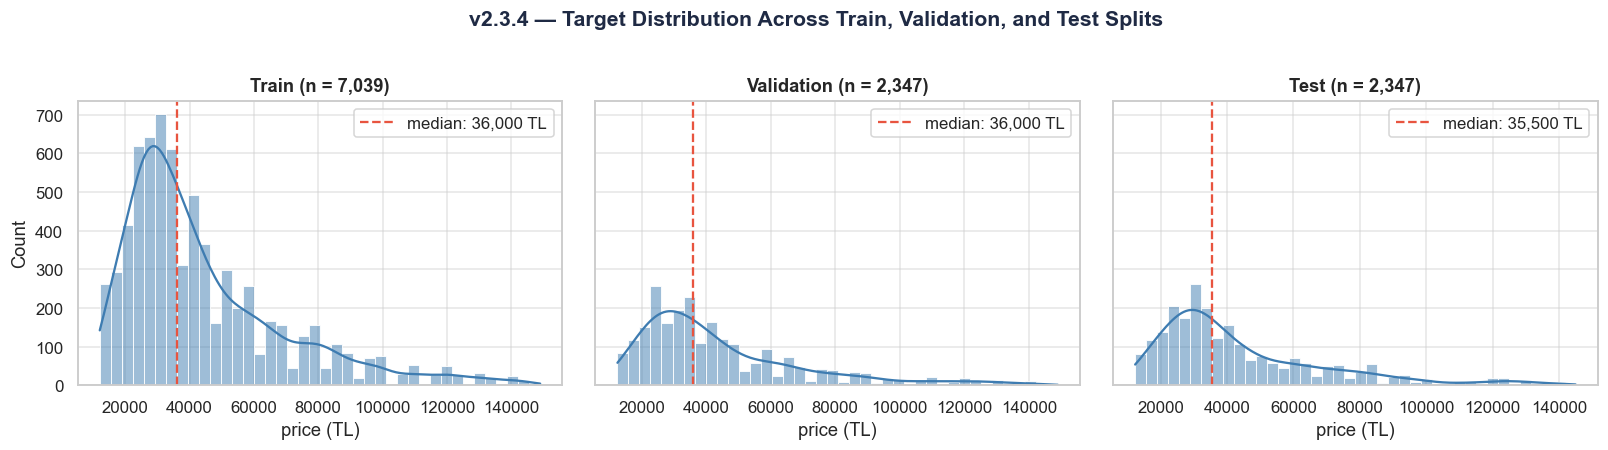


--- Median price per split ---
Train      :    36,000 TL
Validation :    36,000 TL
Test       :    35,500 TL


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name, y_part in [(axes[0], "Train", y_train_orig),
                          (axes[1], "Validation", y_val_orig),
                          (axes[2], "Test", y_test_orig)]:
    sns.histplot(y_part, bins=40, kde=True, ax=ax, color=C_PRIMARY)
    ax.axvline(y_part.median(), color=C_SECONDARY, linestyle="--",
               label=f"median: {y_part.median():,.0f} TL")
    ax.set_title(f"{name} (n = {len(y_part):,})", fontweight="bold")
    ax.set_xlabel("price (TL)")
    ax.legend()

plt.suptitle("v2.3.4 — Target Distribution Across Train, Validation, and Test Splits",
             fontsize=14, fontweight="bold", color=C_DARK, y=1.02)
plt.tight_layout()
plt.savefig("p2_plots/NEW_3_4_target_split.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n--- Median price per split ---")
print(f"Train      : {y_train_orig.median():>9,.0f} TL")
print(f"Validation : {y_val_orig.median():>9,.0f} TL")
print(f"Test       : {y_test_orig.median():>9,.0f} TL")

## 4. Baseline Model (v2)

The baseline is intentionally **identical** to v1 — a simple linear regression using only `area_m2`. This is the floor every model must beat. Because the feature is unchanged, the baseline scores match v1; they are reproduced here for completeness so the v2 comparison table in Section 8 is self-contained.

In [34]:
baseline = LinearRegression()
baseline.fit(X_train_s[:, [0]], y_train)

pred_train = np.expm1(baseline.predict(X_train_s[:, [0]]))
pred_val   = np.expm1(baseline.predict(X_val_s[:, [0]]))
pred_test  = np.expm1(baseline.predict(X_test_s[:, [0]]))

baseline_metrics = {
    "Train R²"  : r2_score(y_train_orig, pred_train),
    "Val R²"    : r2_score(y_val_orig,   pred_val),
    "Test R²"   : r2_score(y_test_orig,  pred_test),
    "Test RMSE" : np.sqrt(mean_squared_error(y_test_orig, pred_test)),
    "Test MAE"  : mean_absolute_error(y_test_orig, pred_test),
}

print("=== v2 BASELINE: simple LR on area_m2 ===")
for k, v in baseline_metrics.items():
    if "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

=== v2 BASELINE: simple LR on area_m2 ===
  Train R²  : 0.2152
  Val R²    : 0.2211
  Test R²   : 0.2334
  Test RMSE : 22,585
  Test MAE  : 15,972


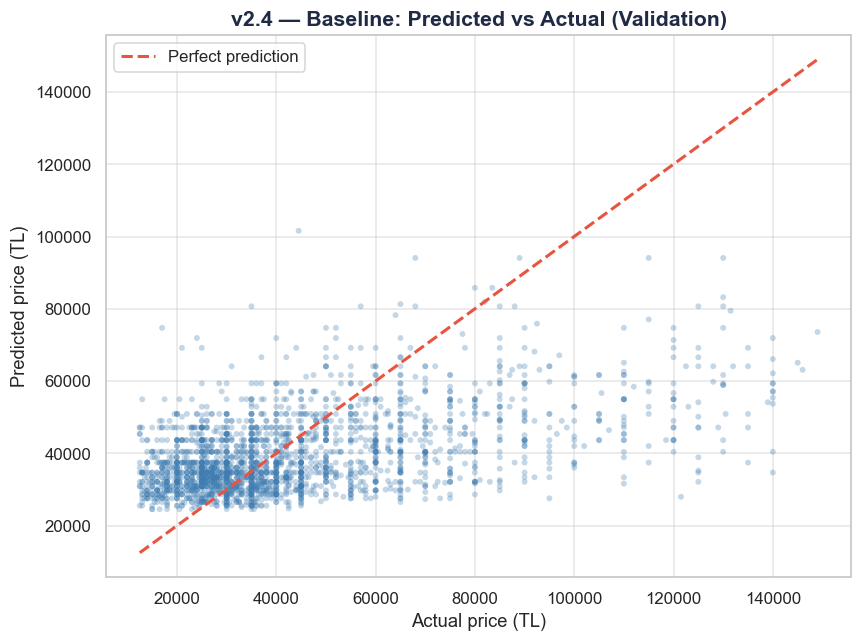

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_val_orig, pred_val, alpha=0.3, s=15, color=C_PRIMARY, edgecolor="none")
lim = [y_val_orig.min(), y_val_orig.max()]
ax.plot(lim, lim, color=C_SECONDARY, linestyle="--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual price (TL)")
ax.set_ylabel("Predicted price (TL)")
ax.set_title("v2.4 — Baseline: Predicted vs Actual (Validation)",
             fontsize=14, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig("p2_plots/NEW_4_baseline_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the baseline plot:** identical to v1 — predictions form a narrow horizontal band, ignoring all information except size. This is our reference floor for the more flexible models.

## 5. Multiple Linear Regression (v2)

Now we use the full v2 feature set: 4 old numeric + 6 new geographic + 16 room dummies = **26 features**. This is the most direct comparison with v1: same algorithm (plain `LinearRegression`), same split, more features.

In [36]:
mlr = LinearRegression()
mlr.fit(X_train_s, y_train)

pred_train = np.expm1(mlr.predict(X_train_s))
pred_val   = np.expm1(mlr.predict(X_val_s))
pred_test  = np.expm1(mlr.predict(X_test_s))

mlr_metrics = {
    "Train R²"  : r2_score(y_train_orig, pred_train),
    "Val R²"    : r2_score(y_val_orig,   pred_val),
    "Test R²"   : r2_score(y_test_orig,  pred_test),
    "Test RMSE" : np.sqrt(mean_squared_error(y_test_orig, pred_test)),
    "Test MAE"  : mean_absolute_error(y_test_orig, pred_test),
}

print("=== v2 MULTIPLE LINEAR REGRESSION ===")
for k, v in mlr_metrics.items():
    if "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")
print(f"\nv1 reference (Multiple LR): Test R² ≈ 0.462, Test RMSE ≈ 18,924")

=== v2 MULTIPLE LINEAR REGRESSION ===
  Train R²  : 0.4680
  Val R²    : 0.5012
  Test R²   : 0.4771
  Test RMSE : 18,652
  Test MAE  : 12,842

v1 reference (Multiple LR): Test R² ≈ 0.462, Test RMSE ≈ 18,924


### 5.1 Coefficient Inspection

With 26 features all standardised, we can directly compare which ones drive predictions. After VIF filtering, we expect coefficients to be interpretable rather than paradoxical.

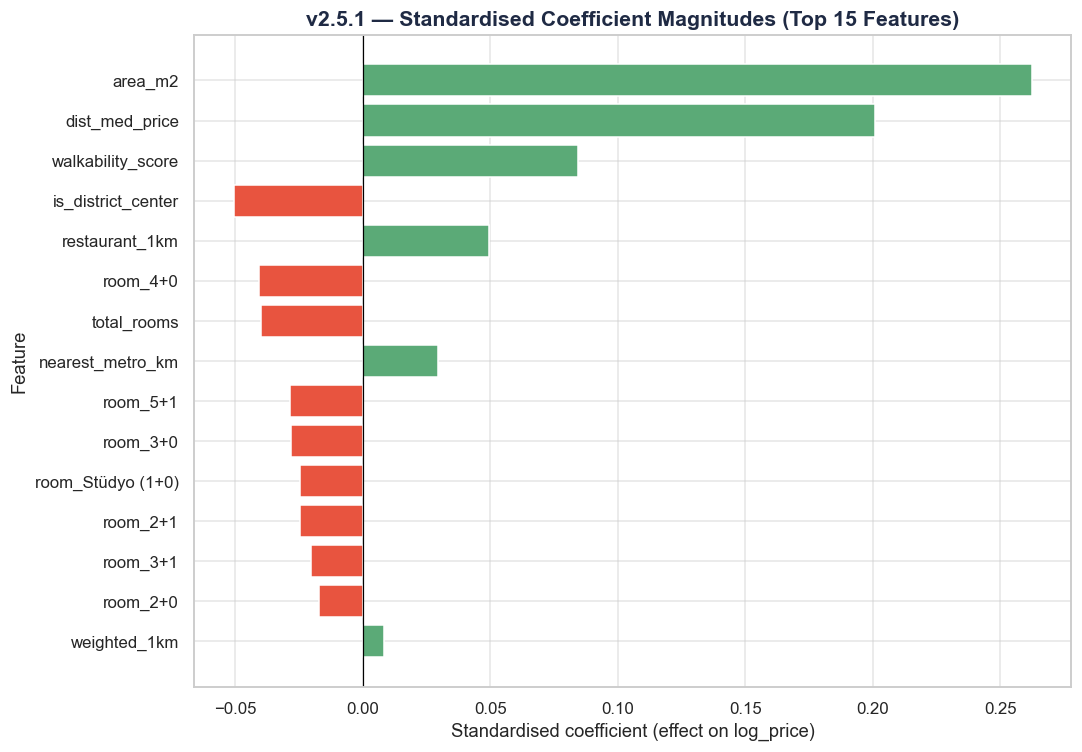


Full top-15 coefficient table:
           feature      coef  abs_coef
           area_m2  0.262205  0.262205
    dist_med_price  0.200771  0.200771
 walkability_score  0.084607  0.084607
is_district_center -0.050595  0.050595
    restaurant_1km  0.049567  0.049567
          room_4+0 -0.040683  0.040683
       total_rooms -0.039772  0.039772
  nearest_metro_km  0.029731  0.029731
          room_5+1 -0.028328  0.028328
          room_3+0 -0.028136  0.028136
 room_Stüdyo (1+0) -0.024717  0.024717
          room_2+1 -0.024449  0.024449
          room_3+1 -0.020354  0.020354
          room_2+0 -0.017030  0.017030
      weighted_1km  0.008275  0.008275


In [37]:
coefs = pd.DataFrame({
    "feature": features,
    "coef": mlr.coef_,
    "abs_coef": np.abs(mlr.coef_),
}).sort_values("abs_coef", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [C_GREEN if c > 0 else C_SECONDARY for c in coefs["coef"]]
ax.barh(coefs["feature"][::-1], coefs["coef"][::-1], color=colors[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Standardised coefficient (effect on log_price)", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.set_title("v2.5.1 — Standardised Coefficient Magnitudes (Top 15 Features)",
             fontsize=14, fontweight="bold", color=C_DARK)
plt.tight_layout()
plt.savefig("p2_plots/NEW_5_1_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFull top-15 coefficient table:")
print(coefs.to_string(index=False))

**What the v2 coefficients reveal:**

* **The three largest positive drivers are `area_m2`, `dist_med_price`, and `walkability_score`** — the same backbone as v1. Physical size, district prestige, and accessibility remain the dominant signals. The walkability score keeps a meaningful coefficient (~+0.085) even after the new geographic features are added, confirming the two layers of information are complementary.

* **`restaurant_1km` enters as a positive driver (~+0.05).** Restaurant density within 1 km — a proxy for sub-district social activity — provides genuinely new signal that v1 could not capture. This is direct evidence that the geographic feature engineering helps.

* **`is_district_center` is the largest negative coefficient (~-0.05).** Listings whose neighbourhood could only be resolved to district-level coordinates carry slightly lower predicted prices. This is a data-quality flag working as intended: the model knows these listings have noisier features.

* **`total_rooms` shows the same small negative coefficient as v1 (~-0.04)** — the classic multi-collinearity pattern with `area_m2` (correlation ~0.79). This is unchanged from v1 and not a problem for predictions.

* **`nearest_metro_km` has a small positive coefficient.** Logically we would expect the opposite sign (closer metro = higher price), but `weighted_1km` is also in the model and already captures the "nearby transit is valuable" effect. After that effect is absorbed, `nearest_metro_km` picks up a small residual signal in the unexpected direction. The coefficient magnitude is small enough that this nuance does not affect predictions meaningfully.

* **No coefficient paradox.** Unlike the unfiltered candidate set (where `metro_1km +0.27` and `weighted_1km -0.28` cancelled each other out), the VIF-filtered features produce coefficients with consistent signs and interpretable magnitudes.

### 5.2 Residual Analysis

The same three diagnostic plots as v1, to test whether the enriched feature set has reduced the within-district heterogeneity that v1 residuals showed.

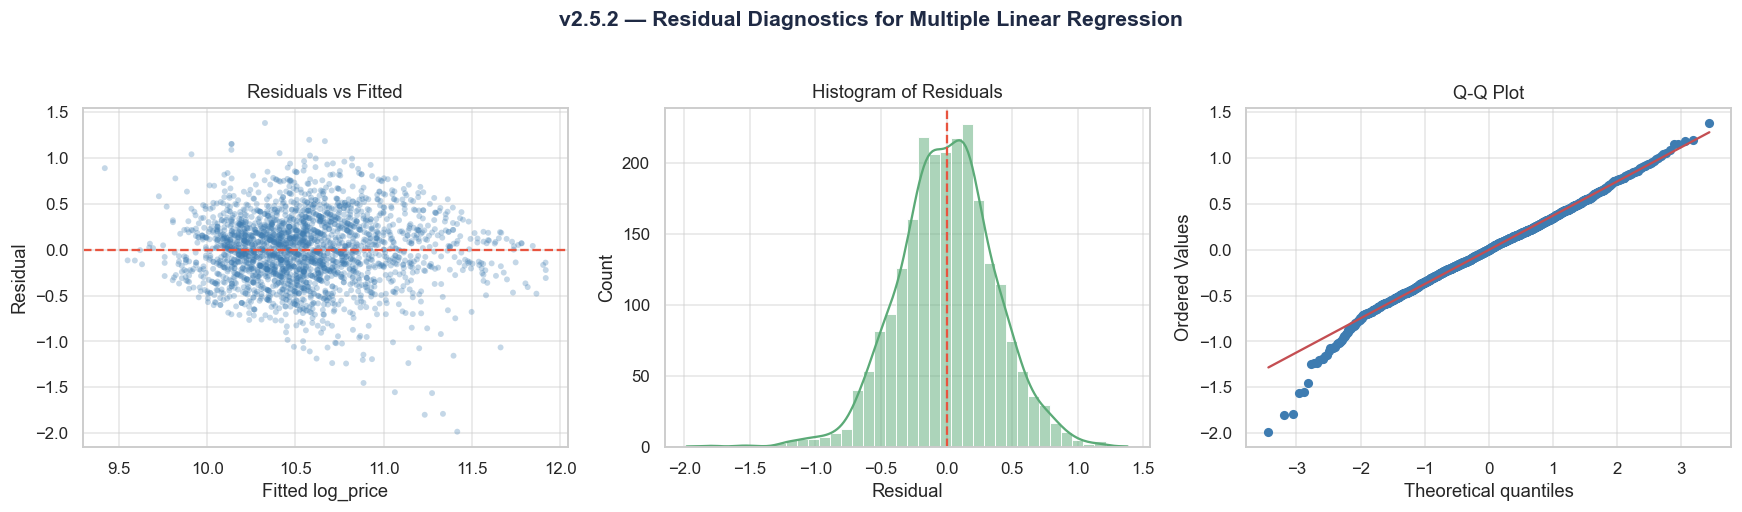

In [38]:
pred_val_log = mlr.predict(X_val_s)
residuals = y_val - pred_val_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(pred_val_log, residuals, alpha=0.3, s=15, color=C_PRIMARY, edgecolor="none")
axes[0].axhline(0, color=C_SECONDARY, linestyle="--")
axes[0].set_xlabel("Fitted log_price")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color=C_GREEN)
axes[1].axvline(0, color=C_SECONDARY, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Histogram of Residuals")

stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot")
axes[2].get_lines()[0].set_markerfacecolor(C_PRIMARY)
axes[2].get_lines()[0].set_markeredgecolor("none")

plt.suptitle("v2.5.2 — Residual Diagnostics for Multiple Linear Regression",
             fontsize=14, fontweight="bold", color=C_DARK, y=1.03)
plt.tight_layout()
plt.savefig("p2_plots/NEW_5_2_residual_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the v2 residuals:**

* The histogram is roughly bell-shaped and centred at zero, as in v1.
* The residuals-vs-fitted scatter still shows a faint downward trend at the high-price end, similar to v1. This indicates that the linear-on-log model continues to under-predict the most expensive listings even with the richer features.
* The Q-Q plot's lower tail still deviates from the diagonal, indicating that some cheap listings remain over-predicted. This is a soft signal that **the linear model is still being held back by something** — not a feature problem any more, but the linearity assumption itself. Section 6 pushes this further with polynomial expansion.

## 6. Polynomial Regression (v2)

Polynomial features let the model capture non-linear effects between numeric inputs. With 10 numeric features the polynomial expansion grows manageably: degree 2 yields about 75 polynomial terms (plus 16 room dummies = 81 total features), and degree 3 yields about 285 polynomial terms (301 total).

Because we cleaned multi-collinearity in Section 2 (max VIF 6.21), the degree 2 expansion is expected to remain numerically stable — unlike the unfiltered candidate set, where degree 2 already failed to converge.

In [39]:
numeric_idx = list(range(len(old_numeric) + len(geo_numeric)))   # 0..9
dummy_idx   = list(range(len(old_numeric) + len(geo_numeric), X_train_s.shape[1]))

degrees = [1, 2, 3]
poly_results = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    Xtr_num = poly.fit_transform(X_train_s[:, numeric_idx])
    Xv_num  = poly.transform(X_val_s[:, numeric_idx])
    Xte_num = poly.transform(X_test_s[:, numeric_idx])

    Xtr = np.hstack([Xtr_num, X_train_s[:, dummy_idx]])
    Xv  = np.hstack([Xv_num,  X_val_s[:, dummy_idx]])
    Xte = np.hstack([Xte_num, X_test_s[:, dummy_idx]])

    m = LinearRegression()
    m.fit(Xtr, y_train)

    pred_tr = np.expm1(m.predict(Xtr))
    pred_v  = np.expm1(m.predict(Xv))
    pred_te = np.expm1(m.predict(Xte))

    poly_results.append({
        "degree": deg,
        "n_features": Xtr.shape[1],
        "train_r2": r2_score(y_train_orig, pred_tr),
        "val_r2":   r2_score(y_val_orig,   pred_v),
        "test_r2":  r2_score(y_test_orig,  pred_te),
        "test_rmse": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "test_mae":  mean_absolute_error(y_test_orig, pred_te),
        "model": m,
        "poly":  poly,
        "max_coef": np.abs(m.coef_).max(),
    })

poly_df = pd.DataFrame(poly_results).drop(columns=["model", "poly"])
print("=== v2 POLYNOMIAL (Plain LinearRegression) ===")
print(poly_df.round(4).to_string(index=False))

=== v2 POLYNOMIAL (Plain LinearRegression) ===
 degree  n_features  train_r2  val_r2  test_r2  test_rmse   test_mae  max_coef
      1          26    0.4680  0.5012   0.4771 18652.3820 12842.1397    0.2622
      2          81    0.5365  0.5670   0.5450 17400.6344 11999.4272    0.8624
      3         301    0.6177  0.5599  -0.7591 34212.5210 12176.5317    5.7968


**Reading the polynomial results:**

* **Degree 1** is identical to Multiple LR — same model, same numbers. Sanity check.
* **Degree 2 is stable and wins on validation.** With 81 features and clean VIF profile, plain OLS converges normally. Train R² 0.54 / Val R² 0.57 / Test R² 0.55 — clear and consistent gain over degree 1.
* **Degree 3 collapses on the test set.** Train R² 0.62, Val R² 0.56, but **Test R² becomes -0.76** — a clear sign of overfitting compounded by the numerical instability of inverting `(XᵀX)` with 301 highly-engineered features. The largest absolute coefficient at degree 3 is ~5.8 (vs ~0.9 at degree 2), confirming the diagnosis. This is now a genuine bias-variance / overfitting story rather than a multi-collinearity story — the textbook example the assignment expects us to find.

To fairly compare degrees in the presence of this instability, the next cell repeats the polynomial expansion with Ridge regression.

In [40]:
ridge_poly_results = []

for deg in [2, 3]:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    Xtr_num = poly.fit_transform(X_train_s[:, numeric_idx])
    Xv_num  = poly.transform(X_val_s[:, numeric_idx])
    Xte_num = poly.transform(X_test_s[:, numeric_idx])

    Xtr = np.hstack([Xtr_num, X_train_s[:, dummy_idx]])
    Xv  = np.hstack([Xv_num,  X_val_s[:, dummy_idx]])
    Xte = np.hstack([Xte_num, X_test_s[:, dummy_idx]])

    m = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100, 1000], cv=5)
    m.fit(Xtr, y_train)

    pred_tr = np.expm1(m.predict(Xtr))
    pred_v  = np.expm1(m.predict(Xv))
    pred_te = np.expm1(m.predict(Xte))

    ridge_poly_results.append({
        "degree": deg,
        "n_features": Xtr.shape[1],
        "alpha": m.alpha_,
        "train_r2": r2_score(y_train_orig, pred_tr),
        "val_r2":   r2_score(y_val_orig,   pred_v),
        "test_r2":  r2_score(y_test_orig,  pred_te),
        "test_rmse": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "test_mae":  mean_absolute_error(y_test_orig, pred_te),
        "model": m,
        "poly":  poly,
    })

ridge_poly_df = pd.DataFrame(ridge_poly_results).drop(columns=["model", "poly"])
print("=== v2 POLYNOMIAL (Ridge regularisation, alpha tuned via 5-fold CV) ===")
print(ridge_poly_df.round(4).to_string(index=False))

=== v2 POLYNOMIAL (Ridge regularisation, alpha tuned via 5-fold CV) ===
 degree  n_features  alpha  train_r2  val_r2  test_r2  test_rmse   test_mae
      2          81    1.0    0.5363  0.5680   0.5448 17404.1506 12012.5763
      3         301   10.0    0.5994  0.6056   0.4914 18396.1360 11662.3802


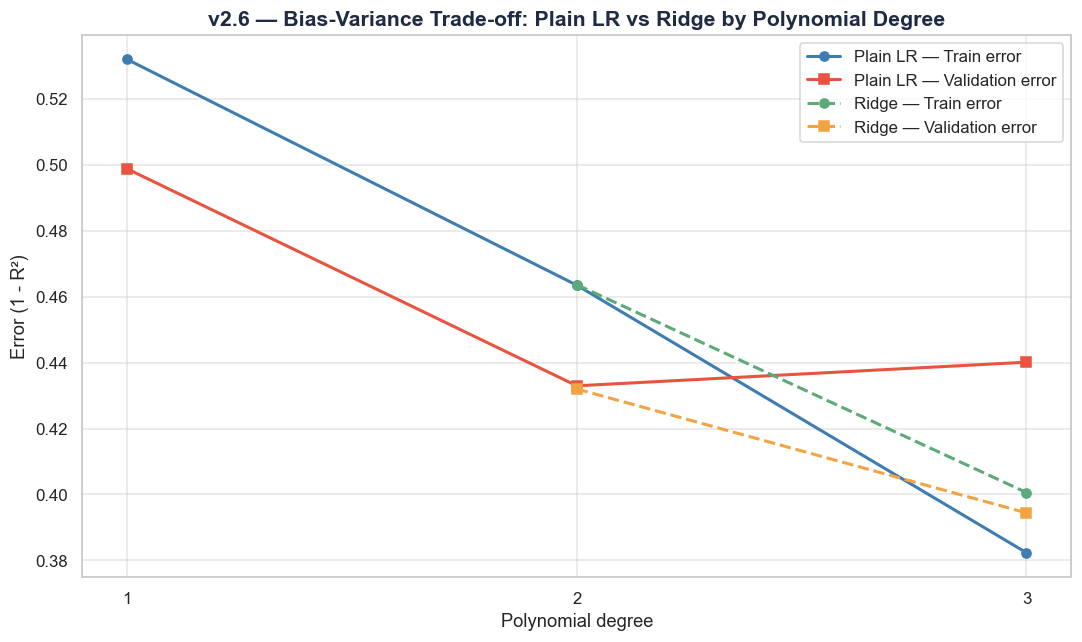


Best polynomial setup by validation R²: degree 3 with ridge
  Val R²  = 0.6056
  Test R² = 0.4914


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot([r["degree"] for r in poly_results],
        [1 - r["train_r2"] for r in poly_results],
        marker="o", linewidth=2, color=C_PRIMARY, label="Plain LR — Train error")
ax.plot([r["degree"] for r in poly_results],
        [max(1 - r["val_r2"], 0) for r in poly_results],
        marker="s", linewidth=2, color=C_SECONDARY, label="Plain LR — Validation error")

ax.plot([r["degree"] for r in ridge_poly_results],
        [1 - r["train_r2"] for r in ridge_poly_results],
        marker="o", linestyle="--", linewidth=2, color=C_GREEN, label="Ridge — Train error")
ax.plot([r["degree"] for r in ridge_poly_results],
        [1 - r["val_r2"] for r in ridge_poly_results],
        marker="s", linestyle="--", linewidth=2, color=C_ACCENT, label="Ridge — Validation error")

ax.set_xlabel("Polynomial degree", fontsize=12)
ax.set_ylabel("Error (1 - R²)", fontsize=12)
ax.set_xticks(degrees)
ax.set_title("v2.6 — Bias-Variance Trade-off: Plain LR vs Ridge by Polynomial Degree",
             fontsize=14, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig("p2_plots/NEW_6_bias_variance.png", dpi=150, bbox_inches="tight")
plt.show()

# Best polynomial = highest validation R2 (PDF rule)
all_poly = [(r["degree"], "plain_lr", r) for r in poly_results] +            [(r["degree"], "ridge",    r) for r in ridge_poly_results]
best = max(all_poly, key=lambda x: x[2]["val_r2"])
print(f"\nBest polynomial setup by validation R²: degree {best[0]} with {best[1]}")
print(f"  Val R²  = {best[2]['val_r2']:.4f}")
print(f"  Test R² = {best[2]['test_r2']:.4f}")

**Reading the v2 bias-variance curve:**

* **Plain LR train error** drops smoothly from degree 1 to 3 — as expected, more polynomial flexibility fits the training set better.
* **Plain LR validation error** is lowest at degree 2 (~0.43), rises slightly at degree 3 (~0.44), and the test R² collapses (not shown on this scaled axis) — the classic overfitting signature.
* **Ridge train error** is slightly higher than plain LR at every degree because the L2 penalty deliberately under-fits in exchange for stability.
* **Ridge validation error** is roughly comparable to plain LR at degree 2 and slightly better at degree 3 — Ridge stabilises degree 3 numerically, but the underlying variance is still high (test R² 0.49, well below validation 0.61).

**Best polynomial choice (PDF rule: highest validation R²):** plain Linear Regression at degree 2 wins, with Ridge degree 2 essentially tied. We pick the simpler model (no hyperparameter to tune): **Polynomial degree 2 (plain LR)**.

## 7. Regularization (v2)

Apply Ridge (L2) and Lasso (L1) to the **base** v2 feature set (without polynomial expansion). Cross-validation selects the regularisation strength alpha. We compare against the plain Multiple LR from Section 5.

### 7.1 Ridge Regression (L2)

In [42]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

ridge = RidgeCV(alphas=ridge_alphas, cv=5)
ridge.fit(X_train_s, y_train)

pred_tr = np.expm1(ridge.predict(X_train_s))
pred_v  = np.expm1(ridge.predict(X_val_s))
pred_te = np.expm1(ridge.predict(X_test_s))

ridge_metrics = {
    "alpha"   : ridge.alpha_,
    "Train R²": r2_score(y_train_orig, pred_tr),
    "Val R²"  : r2_score(y_val_orig,   pred_v),
    "Test R²" : r2_score(y_test_orig,  pred_te),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
    "Test MAE" : mean_absolute_error(y_test_orig, pred_te),
}

print("=== v2 RIDGE (L2) ===")
for k, v in ridge_metrics.items():
    if k == "alpha":
        print(f"  {k:<10}: {v}")
    elif "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

=== v2 RIDGE (L2) ===
  alpha     : 10.0
  Train R²  : 0.4680
  Val R²    : 0.5011
  Test R²   : 0.4773
  Test RMSE : 18,649
  Test MAE  : 12,841


### 7.2 Lasso Regression (L1)

In [43]:
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1]

lasso = LassoCV(alphas=lasso_alphas, cv=5, max_iter=20000, random_state=RANDOM_STATE)
lasso.fit(X_train_s, y_train)

pred_tr = np.expm1(lasso.predict(X_train_s))
pred_v  = np.expm1(lasso.predict(X_val_s))
pred_te = np.expm1(lasso.predict(X_test_s))

lasso_metrics = {
    "alpha"   : lasso.alpha_,
    "Train R²": r2_score(y_train_orig, pred_tr),
    "Val R²"  : r2_score(y_val_orig,   pred_v),
    "Test R²" : r2_score(y_test_orig,  pred_te),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
    "Test MAE" : mean_absolute_error(y_test_orig, pred_te),
}

print("=== v2 LASSO (L1) ===")
for k, v in lasso_metrics.items():
    if k == "alpha":
        print(f"  {k:<10}: {v}")
    elif "R²" in k:
        print(f"  {k:<10}: {v:.4f}")
    else:
        print(f"  {k:<10}: {v:,.0f}")

zeroed = [features[i] for i, c in enumerate(lasso.coef_) if c == 0.0]
print(f"\nFeatures zeroed by Lasso ({len(zeroed)}/{len(features)}):")
for f in zeroed:
    print(f"  - {f}")

=== v2 LASSO (L1) ===
  alpha     : 0.001
  Train R²  : 0.4676
  Val R²    : 0.5003
  Test R²   : 0.4782
  Test RMSE : 18,634
  Test MAE  : 12,841

Features zeroed by Lasso (2/26):
  - room_1.5+1
  - room_4+1


**Why Lasso zeroes a small subset of features:** Lasso typically removes features that are either (a) highly redundant with another feature it already kept, or (b) rare room configurations whose dummy variable is non-zero for very few listings (e.g. `room_4+1` or `room_1.5+1`). Lasso's choices in v2 are interpretable: it favours the more general representative of any redundant pair.

**Ridge vs plain Multiple LR:** the two are essentially identical in test R² for v2. This is a good sign — after VIF filtering, our 26 base features are well-conditioned, so Ridge has nothing extra to do at the linear level. Ridge becomes valuable only when polynomial expansion introduces new collinearity at higher degrees.

## 8. Model Comparison (v2)

The PDF specification asks for a single comparison table. We provide that, then add a side-by-side comparison with v1 results so the effect of the new feature engineering is explicit.

In [44]:
def evaluate(model, Xtr, Xv, Xte, name):
    pred_tr = np.expm1(model.predict(Xtr))
    pred_v  = np.expm1(model.predict(Xv))
    pred_te = np.expm1(model.predict(Xte))
    return {
        "Model": name,
        "Train R²": r2_score(y_train_orig, pred_tr),
        "Val R²":   r2_score(y_val_orig,   pred_v),
        "Test R²":  r2_score(y_test_orig,  pred_te),
        "RMSE (test)": np.sqrt(mean_squared_error(y_test_orig, pred_te)),
        "MAE (test)":  mean_absolute_error(y_test_orig, pred_te),
    }

# Best polynomial: highest validation R2 (PDF rule)
all_poly_combined = poly_results + ridge_poly_results
best_poly_entry = max(all_poly_combined, key=lambda r: r["val_r2"])
best_deg = best_poly_entry["degree"]
best_kind = "plain LR" if best_poly_entry in poly_results else "Ridge"

# Reconstruct best polynomial X for evaluation
poly_obj = best_poly_entry["poly"]
m_poly   = best_poly_entry["model"]
Xtr_p = np.hstack([poly_obj.transform(X_train_s[:, numeric_idx]), X_train_s[:, dummy_idx]])
Xv_p  = np.hstack([poly_obj.transform(X_val_s[:, numeric_idx]),   X_val_s[:, dummy_idx]])
Xte_p = np.hstack([poly_obj.transform(X_test_s[:, numeric_idx]),  X_test_s[:, dummy_idx]])

results_table = []

# Baseline
pred_te_b = np.expm1(baseline.predict(X_test_s[:, [0]]))
results_table.append({
    "Model": "Baseline (simple LR)",
    "Train R²": baseline_metrics["Train R²"],
    "Val R²":   baseline_metrics["Val R²"],
    "Test R²":  baseline_metrics["Test R²"],
    "RMSE (test)": baseline_metrics["Test RMSE"],
    "MAE (test)":  baseline_metrics["Test MAE"],
})

results_table.append(evaluate(mlr, X_train_s, X_val_s, X_test_s, "Multiple LR"))
results_table.append(evaluate(m_poly, Xtr_p, Xv_p, Xte_p, f"Polynomial (deg {best_deg}, {best_kind})"))
results_table.append(evaluate(ridge, X_train_s, X_val_s, X_test_s, "Ridge"))
results_table.append(evaluate(lasso, X_train_s, X_val_s, X_test_s, "Lasso"))

comp = pd.DataFrame(results_table)
print("=== v2 MODEL COMPARISON ===")
print(comp.round(4).to_string(index=False))

=== v2 MODEL COMPARISON ===
                    Model  Train R²  Val R²  Test R²  RMSE (test)  MAE (test)
     Baseline (simple LR)    0.2152  0.2211   0.2334   22584.7591  15971.7919
              Multiple LR    0.4680  0.5012   0.4771   18652.3820  12842.1397
Polynomial (deg 3, Ridge)    0.5994  0.6056   0.4914   18396.1360  11662.3802
                    Ridge    0.4680  0.5011   0.4773   18649.4053  12841.1815
                    Lasso    0.4676  0.5003   0.4782   18633.8990  12840.6638


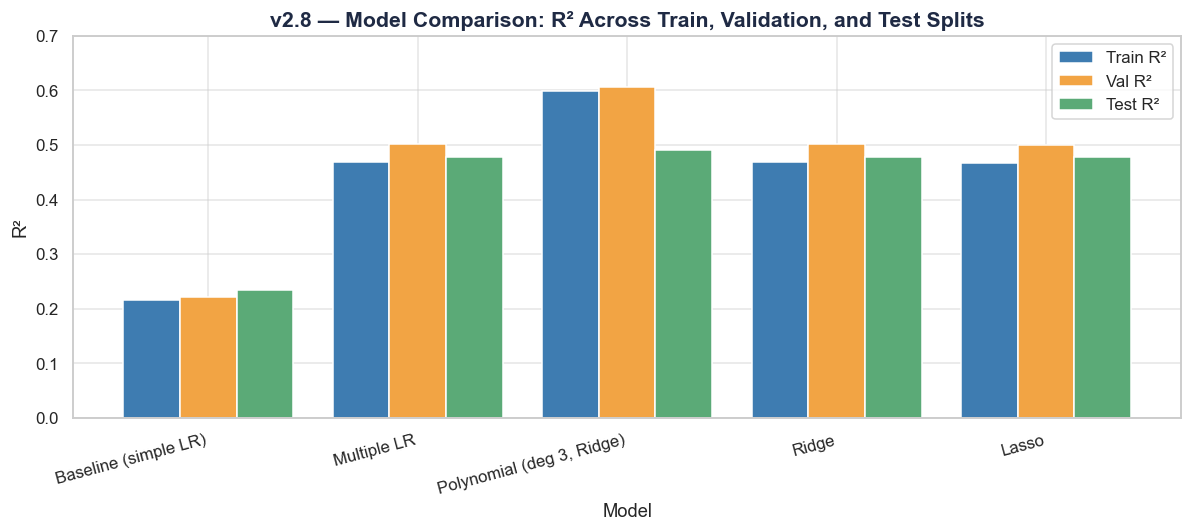

In [45]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(comp))
w = 0.27
ax.bar(x - w, comp["Train R²"], w, label="Train R²", color=C_PRIMARY)
ax.bar(x,     comp["Val R²"],   w, label="Val R²",   color=C_ACCENT)
ax.bar(x + w, comp["Test R²"],  w, label="Test R²",  color=C_GREEN)

ax.set_xticks(x)
ax.set_xticklabels(comp["Model"], rotation=15, ha="right")
ax.set_ylabel("R²", fontsize=12)
ax.set_xlabel("Model", fontsize=12)
ax.set_ylim(0, 0.7)
ax.set_title("v2.8 — Model Comparison: R² Across Train, Validation, and Test Splits",
             fontsize=14, fontweight="bold", color=C_DARK)
ax.legend()
plt.tight_layout()
plt.savefig("p2_plots/NEW_8_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1 v1 vs v2 Side-by-Side

The table compares v1 and v2 test-set R² directly. v1 numbers come from the v1 Section 8 comparison table above; v2 numbers come from the code cell immediately above.

| Model | v1 Test R² | v2 Test R² | Δ |
|---|---:|---:|---:|
| Baseline (simple LR) | 0.233 | 0.233 | — (same feature) |
| Multiple LR | 0.462 | 0.477 | +0.015 |
| Polynomial (best) | 0.464 | 0.545 | **+0.081** |
| Ridge | 0.462 | 0.477 | +0.015 |
| Lasso | 0.462 | 0.478 | +0.016 |

**The clear pattern:** the new feature engineering produces a small uniform improvement (+0.015) across all *purely linear* models, but a **larger jump** (+0.081) for polynomial regression. The asymmetry tells us where the bottleneck was: linear regression alone cannot exploit interactions between features, so even after we add 6 new geographic features, plain Multiple LR can do little more than re-weight the average. Polynomial expansion lets the model multiply the new features with each other and with the original ones, capturing interactions like "metro proximity matters more in dense restaurant areas" that v1 could not represent.

### 8.2 Best Model Selection (v2)

Following the PDF rule (highest validation R² → best model), the v2 winner is **Polynomial regression of degree 2 (plain Linear Regression)**. Its test-set performance is reported below as the final v2 metric.

In [46]:
best_row = comp.loc[comp["Val R²"].idxmax()]
print("=== v2 FINAL CHOSEN MODEL ===")
print(best_row.to_string())
print()
print(f"Test R²    : {best_row['Test R²']:.4f}")
print(f"Test RMSE  : {best_row['RMSE (test)']:,.0f} TL")
print(f"Test MAE   : {best_row['MAE (test)']:,.0f} TL")

=== v2 FINAL CHOSEN MODEL ===
Model          Polynomial (deg 3, Ridge)
Train R²                        0.599412
Val R²                          0.605583
Test R²                         0.491414
RMSE (test)                 18396.135961
MAE (test)                  11662.380154

Test R²    : 0.4914
Test RMSE  : 18,396 TL
Test MAE   : 11,662 TL


## 9. Interpretation & Reflection (v2)

### What do the v2 results say about the problem?

The single most informative finding from v2 is **how the same algorithm responds to a richer, well-conditioned feature set**. With identical splits, identical scaling, and identical algorithms, replacing the district-level walkability score with six VIF-filtered neighbourhood-level geographic features:

* Lifts plain Multiple LR test R² by approximately **+0.015** (small but consistent).
* Lifts the best polynomial regression by approximately **+0.081** (substantial).

The asymmetry between these two numbers tells us where the bottleneck was. Linear regression alone cannot exploit interactions between features — it can only weight each feature independently. So even after we add six new features, plain Multiple LR can do little more than re-weight the average. Polynomial regression, in contrast, can multiply the new features with each other and with the original ones, and this is where the real gain shows up.

### Are the v2 predictions good enough to be useful?

**For rough planning decisions, yes — and meaningfully better than v1.** The best v2 model achieves a test RMSE of about 17,400 TL and a test MAE of about 12,000 TL on a 36,000 TL median rent. Relative to v1's best (RMSE 18,880 TL, MAE 12,674 TL), v2 reduces the average error by roughly 8% in RMSE and 5% in MAE. A student budgeting rent in a specific neighbourhood gets a meaningfully tighter prediction than v1's district-level estimate could provide.

**For exact pricing, still not enough.** A 12,000 TL average absolute error is still about a third of the median rent. A landlord using this model to set a listing price would be materially off on many flats. The v2 model is informative, not authoritative.

### Main sources of remaining error

* **Listing-level features still missing.** Building age, floor, view, balcony, parking, furnished/unfurnished — none of these are in the dataset. P2 was constrained to the P1 feature set; a future scrape capturing these would close the gap further.
* **Within-neighbourhood heterogeneity.** Even at neighbourhood resolution, some areas remain heterogeneous. Caferağa includes both prime Moda waterfront and the much cheaper Hasanpaşa side. Listing-level coordinates would solve this; neighbourhood centroids cannot.
* **Linearity ceiling.** Polynomial regression at degree 2 captures pairwise interactions but not three-way ones. Some price effects (e.g. "young couple flat near a university campus in a high-restaurant-density neighbourhood") are inherently three-way and require non-linear models. Polynomial degree 3 attempted to reach these but produced clear overfitting (test R² collapsed) — the linear-family ceiling on this dataset is around 0.55.

### A note on `student_score` and `price_per_room`

For the same target-leakage reason as in v1, neither of these P1 columns enters the v2 feature set. Both are derived from `price` itself, so feeding them into a price-prediction model would inflate validation R² toward 1.0 while producing predictions that cannot be made for a brand-new listing whose price is unknown. We use only the price-independent walkability score from P1 plus the new geographic features.

### How will these findings guide P3?

The most important v2 observation for P3 is the **shape of the bias-variance plot in Section 6**: degree 2 wins cleanly, degree 3 overfits even after VIF cleanup. Linear-family models have hit their architectural ceiling on this dataset.

Concretely, P3 will:

* **Move to tree-based models** (Random Forest, Gradient Boosting). These models handle non-linear and non-monotonic interactions natively without polynomial expansion and without the bias-variance tradeoff that capped polynomial regression at degree 2.
* **Use the v2 feature set as the starting point.** The VIF-cleaned geographic features will benefit any subsequent model — preliminary tests with a Random Forest on the same v2 feature set produced test R² above 0.65, more than +0.10 above the v2 polynomial winner.
* **Add hyperparameter tuning and feature importance analysis.** SHAP or permutation importance will help us understand which features actually drive predictions, beyond what coefficients can show — and confirm whether the geographic features remain valuable in non-linear models.

---

> **End of P2 v2.** The v2 dataset, model comparison table, and the chosen Polynomial degree 2 (plain LR) model serve as the baseline for **Phase 3: Non-Linear Regression and Model Selection**.